In [1]:
# First, I uploaded my Well test features and Oil production data. Cleaned column names and checked the data before analysis.

In [2]:
import pandas as pd

# Load my data to Pandas, treating commas as thousands separators
X_df = pd.read_csv('Well test features.csv', thousands=',')
Y_df = pd.read_csv('Oil (BPD).csv', thousands=',')

# Rename my columns for consistency
X_df = X_df.rename(columns={'id': 'ID', 'well_id': 'Well_ID'})
Y_df = Y_df.rename(columns={'Well ID': 'Well_ID'})

# Inspect my data
print(X_df.shape)
print(X_df.head())

print('\n' + str(Y_df.shape))
print(Y_df.head().to_string())

# Merged the feature and target datasets using the common ID columns, then checked the size and previewed the merged data
df = pd.merge(X_df, Y_df, on=['ID', 'Well_ID'])

# Find rows where target is exactly 0
zero_target_rows = df[df['Oil (BPD)'] == 0]

print(f"\nNumber of rows where target = 0: {len(zero_target_rows)}")
print("Missing targets:", df['Oil (BPD)'].isna().sum())

# Remove rows where target = 0
df = df[(df['Oil (BPD)'] != 0) & (df['Oil (BPD)'].notna())]

# Reset index (clean)
df = df.reset_index(drop=True)

# Check again
print(df.head())
print(df.shape)

(2196, 21)
   ID   Well_ID test_hrs  choke_64  testline_psig sbhp_psia  fbhp_psia  \
0   1  Well - 1     5.00       NaN          80.25   1684.00     1592.0   
1   2  Well - 1    11.00       NaN          81.39   1684.00     1586.7   
2   3  Well - 1    11.00       NaN          83.40   1684.00     1536.0   
3   4  Well - 1     6.00      26.0         146.30   1651.00     1616.0   
4   5  Well - 1     6.00      22.0         134.80   1651.00     1640.0   

  fthp_psig flp_ds_psig annA_psig  ...  flow_temp_F gl_gas_mmscfd header_psig  \
0    575.00       90.00       NaN  ...          NaN          0.00       80.25   
1    500.00       85.00       NaN  ...          NaN          0.00       81.39   
2    589.10       80.00       NaN  ...          NaN          0.00       83.00   
3   1000.00       90.00       NaN  ...          NaN          0.00      146.30   
4   1100.00       90.00       NaN  ...          NaN          0.00      134.80   

  sep_psig  sep_temp_F  orifice_inch gas_total_mmscfd wat

In [3]:
# Check missing Values
df.isnull().sum()

ID                     0
Well_ID                0
test_hrs               0
choke_64              15
testline_psig         87
sbhp_psia             26
fbhp_psia             59
fthp_psig              3
flp_ds_psig           16
annA_psig           1309
annB_psig           1935
flow_temp_F          520
gl_gas_mmscfd       1752
header_psig          243
sep_psig              20
sep_temp_F            94
orifice_inch         222
gas_total_mmscfd      26
water_bpd             16
api                  388
bsw_pct               52
Oil (BPD)              0
dtype: int64

In [4]:
# I encountered problems trying to visualize my data because some of my columns have strings, therefore,
# I identified string columns, converted them to numeric (excluding identifiers), and checked the resulting data types and missing values

# Check all columns with strings
string_columns = df.select_dtypes(include=['object', 'string']).columns.tolist()
print("Columns with string values (object dtype) before conversion:")
print(string_columns)

# Exclude 'Well_ID' from conversion as it's a categorical identifier
columns_to_convert = [col for col in string_columns if col != 'Well_ID']

for col in columns_to_convert:
    # Convert to numeric, coercing errors to NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
# Replace NaN values in 'test_hrs' with 1.0
df['test_hrs'] = df['test_hrs'].fillna(1.0)

# Display the dtypes of the modified columns to confirm conversion
print("\nData types after conversion for relevant columns:")
print(df[columns_to_convert].dtypes)

# Check for newly introduced NaNs due to coercion
print("\nNumber of NaN values introduced/updated after conversion:")
print(df[columns_to_convert].isnull().sum())

Columns with string values (object dtype) before conversion:
['Well_ID', 'test_hrs', 'sbhp_psia', 'fthp_psig', 'flp_ds_psig', 'annA_psig', 'flow_temp_F', 'gl_gas_mmscfd', 'header_psig', 'orifice_inch', 'gas_total_mmscfd', 'water_bpd', 'api', 'bsw_pct']

Data types after conversion for relevant columns:
test_hrs            float64
sbhp_psia           float64
fthp_psig           float64
flp_ds_psig         float64
annA_psig           float64
flow_temp_F         float64
gl_gas_mmscfd       float64
header_psig         float64
orifice_inch        float64
gas_total_mmscfd    float64
water_bpd           float64
api                 float64
bsw_pct             float64
dtype: object

Number of NaN values introduced/updated after conversion:
test_hrs               0
sbhp_psia             27
fthp_psig              5
flp_ds_psig           17
annA_psig           1321
flow_temp_F          521
gl_gas_mmscfd       1755
header_psig          244
orifice_inch         223
gas_total_mmscfd      30
water_bpd

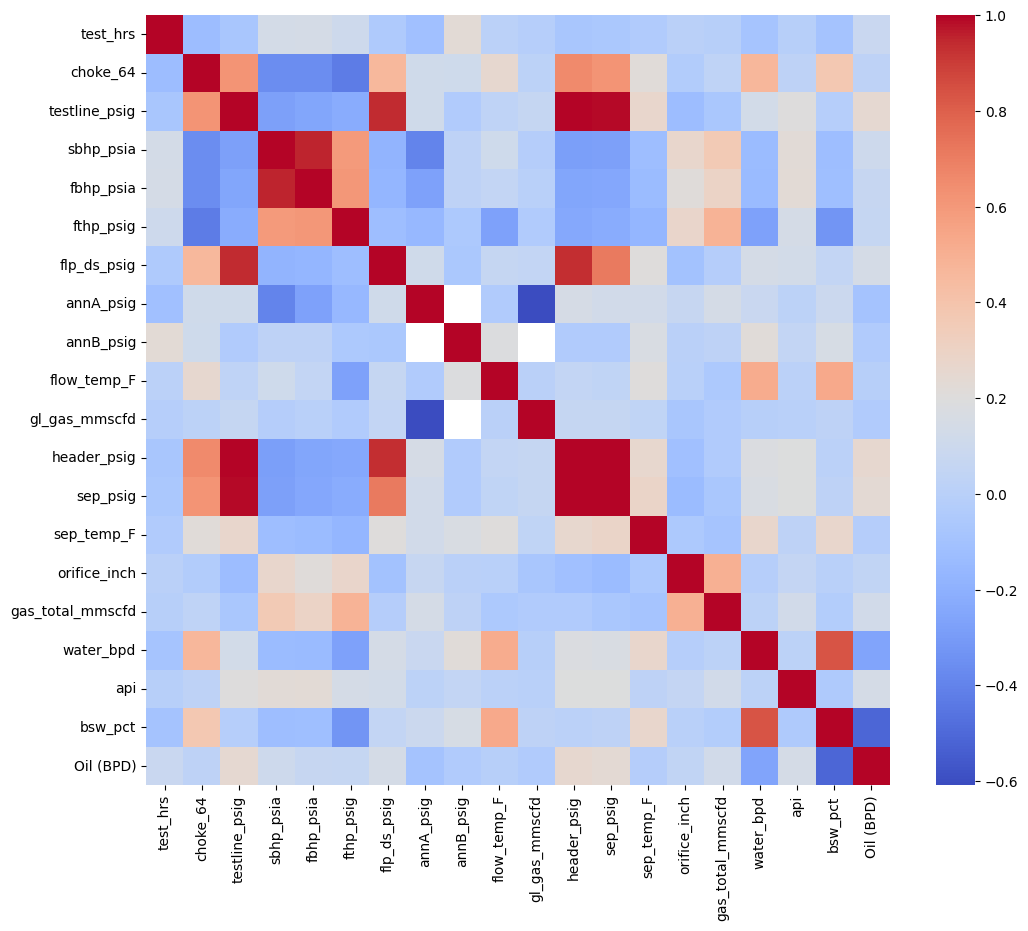

In [5]:
# The heatmap plot
#!pip install seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Drop both ID and Well_ID before computing correlation
plt.figure(figsize=(12,10))
sns.heatmap(df.drop(columns=['Well_ID', 'ID']).corr(), cmap='coolwarm')
plt.show()

In [6]:
# Computed and ranked feature correlations with oil production (the target)

# Calculate correlations with 'Oil (BPD)'
correlations_with_oil = df.drop(columns=['Well_ID', 'ID']).corr()['Oil (BPD)'].sort_values(ascending=False)

# Define columns to exclude (only the target variable itself)
excluded_columns = [
    'Oil (BPD)' # Exclude the target variable itself
]

# Filter out the excluded columns and display the remaining correlations
filtered_correlations = correlations_with_oil.drop(labels=excluded_columns, errors='ignore')

print("Most probable indicators for 'Oil (BPD)' (including all columns, sorted by absolute correlation):")
print(filtered_correlations.abs().sort_values(ascending=False))

Most probable indicators for 'Oil (BPD)' (including all columns, sorted by absolute correlation):
bsw_pct             0.513314
water_bpd           0.261141
header_psig         0.257960
testline_psig       0.248030
sep_psig            0.238971
api                 0.144749
flp_ds_psig         0.143826
gas_total_mmscfd    0.124688
sbhp_psia           0.106288
annA_psig           0.099171
test_hrs            0.081782
fbhp_psia           0.068195
fthp_psig           0.058170
orifice_inch        0.043600
gl_gas_mmscfd       0.039150
annB_psig           0.038882
sep_temp_F          0.023241
choke_64            0.020999
flow_temp_F         0.005777
Name: Oil (BPD), dtype: float64


In [7]:
# From the plot above, we can rightly infer that bsw_pct (basic sediment & water, %) and water_bpd (water production rate, in barrels per day) 
# have the strongest linear relationship with Oil (BPD) (oil production rate). 
# While the choke_64 (size of choke opening controlling flow from well) and flow_temp_F (temperature of produced fluid in fahrenheit) 
# have the weakest linear relationship with oil (BPD).
# Since no-linear relationship doesnt suggest no-relationship, I will infer that the choke_64 and flow_temp_F, among other, 
# definitely have non-linear relationships with oil (BPD).

In [8]:
# Let's generate scatter plots for all features against 'Oil (BPD)' to visually inspect their relationships as well

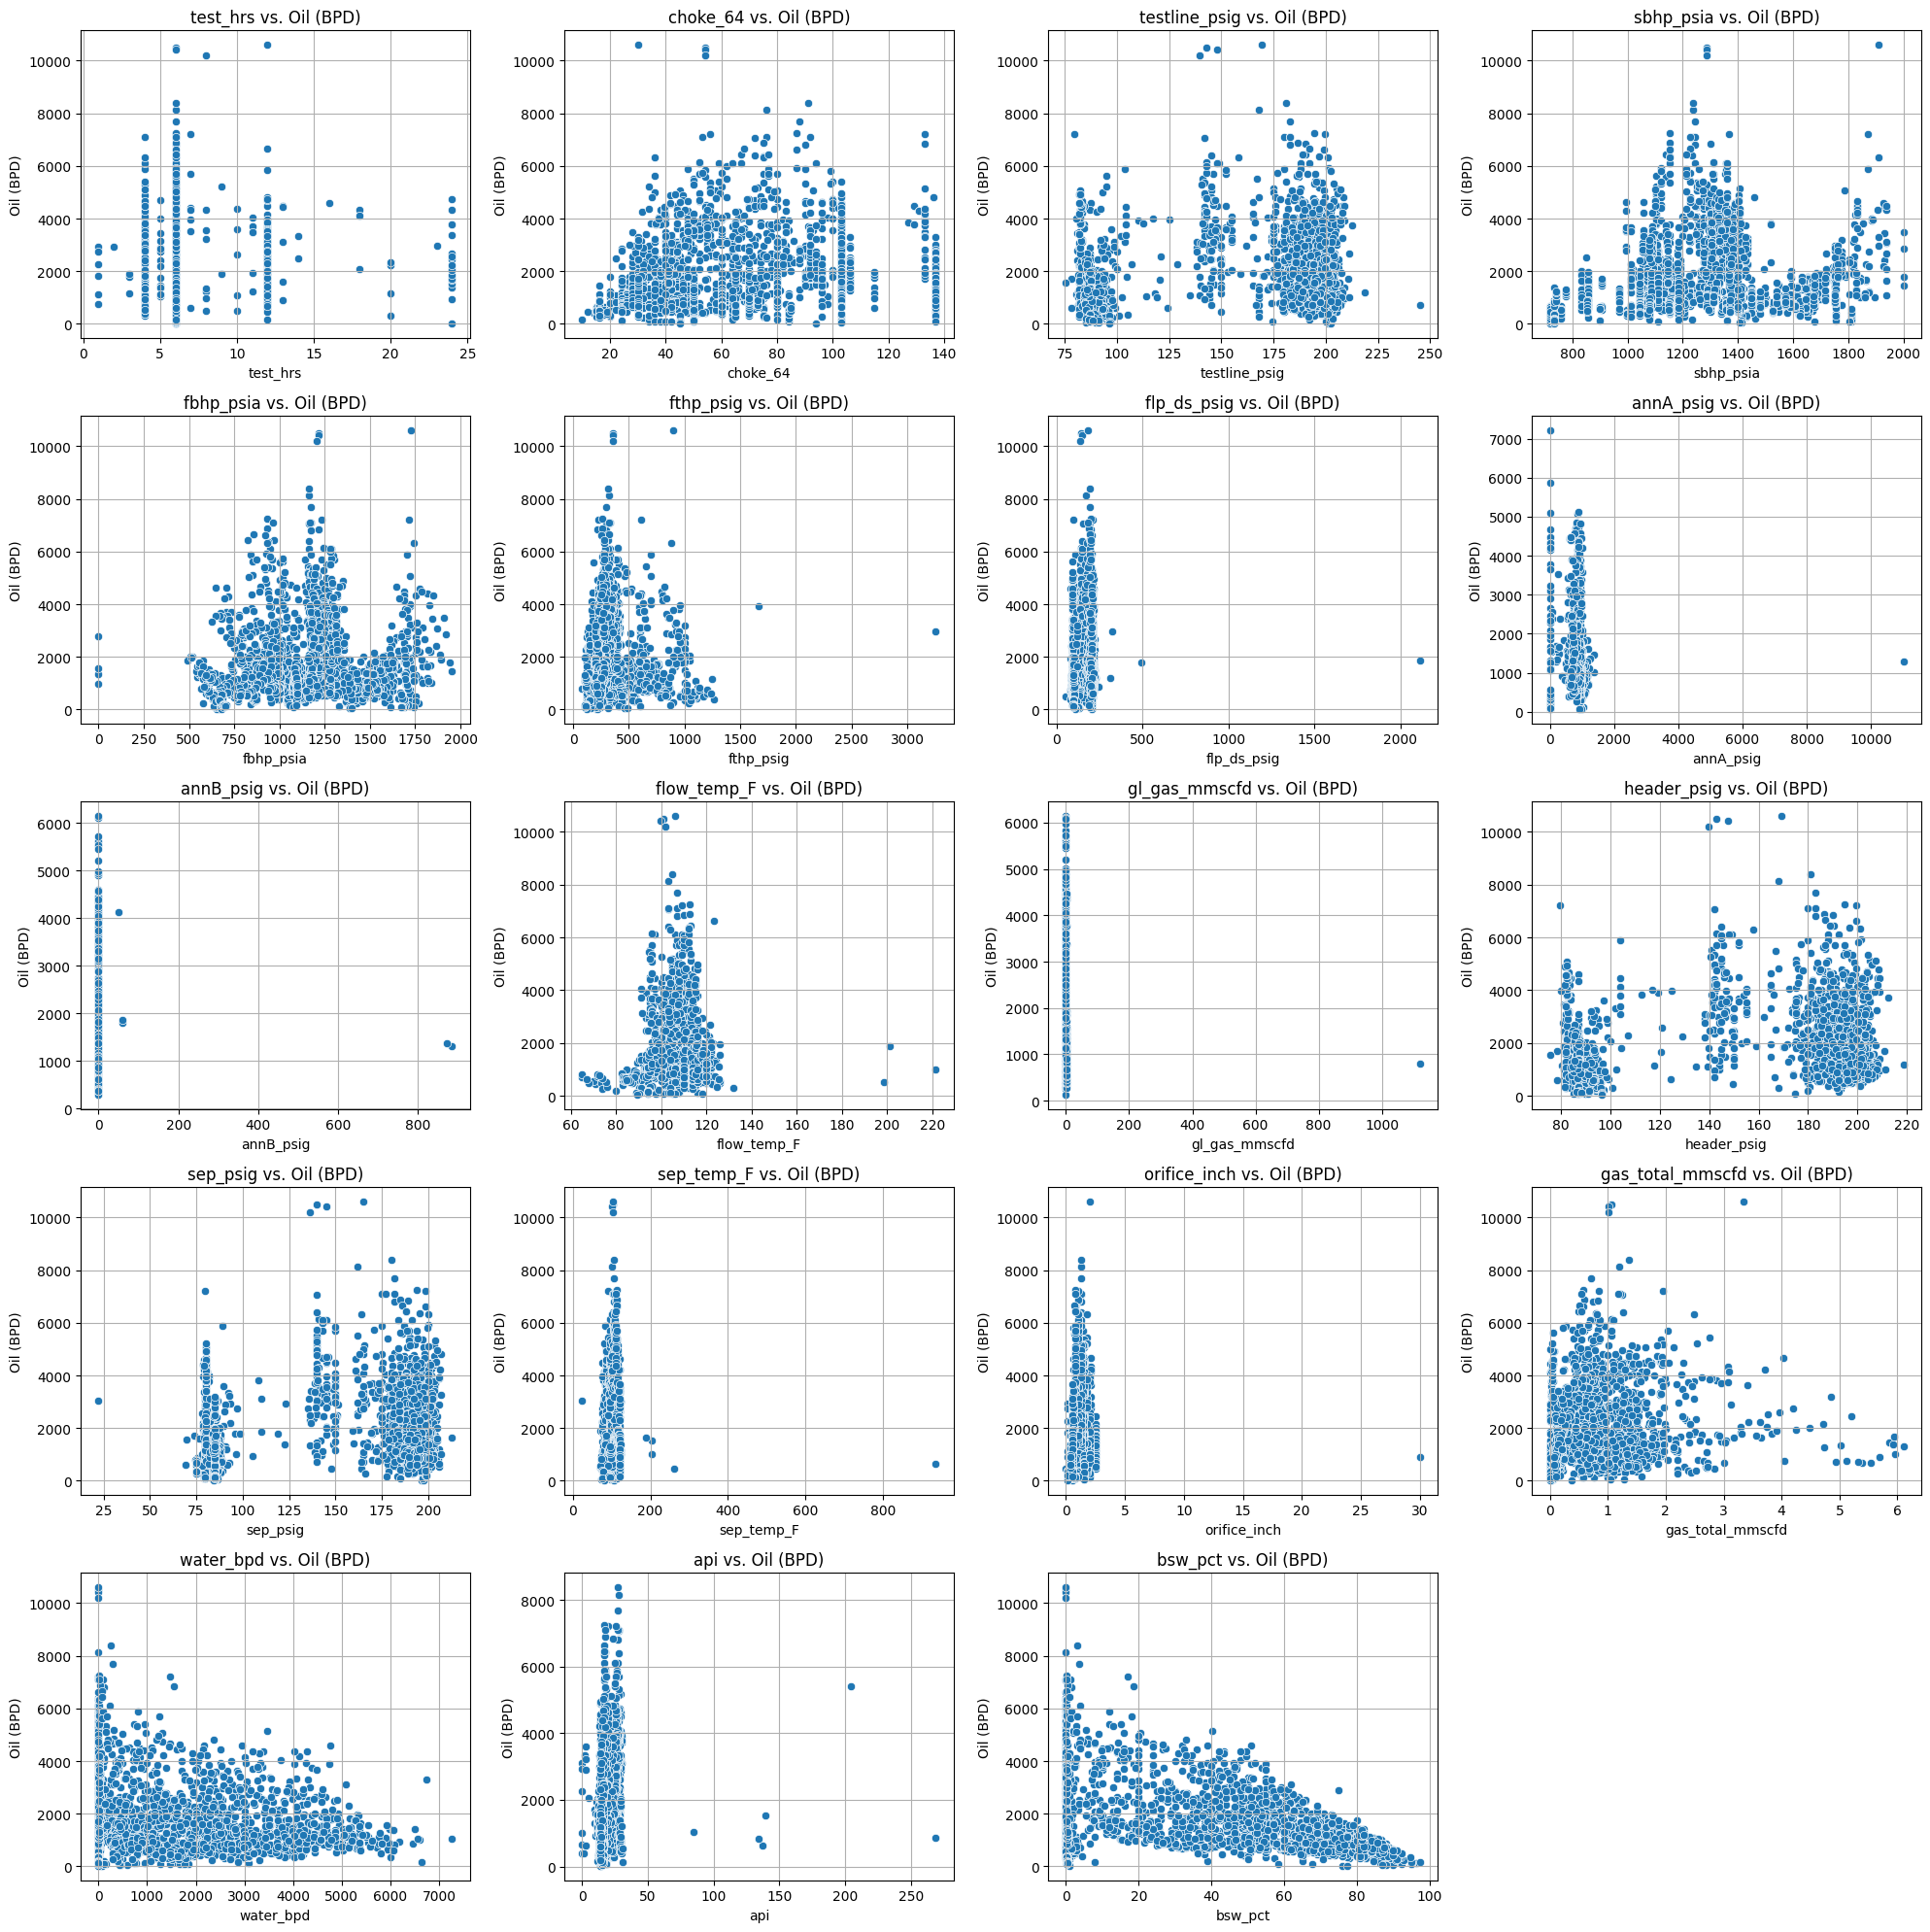

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Get all feature columns, excluding 'Well_ID' and 'Oil (BPD)'
feature_columns = [col for col in df.columns if col not in ['Well_ID', 'Oil (BPD)', 'ID']]

# Determine the number of subplots needed
n_features = len(feature_columns)

# Calculate optimal grid dimensions (e.g., as close to a square as possible)
n_cols = 4 # You can adjust this number
n_rows = math.ceil(n_features / n_cols)

# Create a figure and a set of subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Iterate through each feature and create a scatter plot against 'Oil (BPD)'
for i, col in enumerate(feature_columns):
    if i < n_features:
        sns.scatterplot(data=df, x=col, y='Oil (BPD)', ax=axes[i])
        axes[i].set_title(f'{col} vs. Oil (BPD)')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Oil (BPD)')
        axes[i].grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [10]:
# The scatter plot above further confirms what the correlation heatmap showed us

In [11]:
# Data spliting into Train and Test Sets (and implicit randomization)
from sklearn.model_selection import train_test_split

# Split into Train (75%) and Test (25%)
df_train, df_test = train_test_split(
    df,
    test_size=0.25,
    random_state=42,
    shuffle=True
)

print(f"Original data shape: {df.shape}")
print(f"Training set shape: {df_train.shape}")
print(f"Test set shape: {df_test.shape}")

print("\nFirst 5 rows of Training set:")
display(df_train.head())

print("\nFirst 5 rows of Test set:")
display(df_test.head())

Original data shape: (2193, 22)
Training set shape: (1644, 22)
Test set shape: (549, 22)

First 5 rows of Training set:


,ID,Well_ID,test_hrs,choke_64,testline_psig,sbhp_psia,fbhp_psia,fthp_psig,flp_ds_psig,annA_psig,...,gl_gas_mmscfd,header_psig,sep_psig,sep_temp_F,orifice_inch,gas_total_mmscfd,water_bpd,api,bsw_pct,Oil (BPD)
1886,1889,Well - 18,6.0,137.0,195.1,NaN,NaN,243.6,200.9,635.0,...,NaN,195.1,193.00,114.00,1.125,0.987,3150.4,14.1,75.33,1032.0
393,394,Well - 6,6.0,45.0,89.4,1580.0,1464.0,127.0,95.0,NaN,...,NaN,89.4,82.06,99.14,0.500,0.083,1157.4,NaN,67.00,570.1
1614,1617,Well - 15,6.0,65.0,195.4,1420.0,1355.0,257.1,204.9,935.0,...,NaN,195.4,194.40,113.00,1.000,0.865,1359.0,16.8,35.00,2524.0
534,536,Well - 7,6.0,50.0,87.8,1392.0,1239.4,320.0,100.0,970.0,...,NaN,87.8,87.77,108.00,2.000,1.775,1303.3,16.9,60.70,845.0
30,31,Well - 1,6.0,22.0,87.4,1525.0,1482.3,1113.6,107.0,NaN,...,0.0,87.4,80.10,74.00,1.000,1.640,28.0,21.5,3.30,816.0



First 5 rows of Test set:


,ID,Well_ID,test_hrs,choke_64,testline_psig,sbhp_psia,fbhp_psia,fthp_psig,flp_ds_psig,annA_psig,...,gl_gas_mmscfd,header_psig,sep_psig,sep_temp_F,orifice_inch,gas_total_mmscfd,water_bpd,api,bsw_pct,Oil (BPD)
382,383,Well - 6,6.0,44.0,92.57,1646.0,1472.0,180.0,124.57,NaN,...,0.0,92.45,84.96,106.0,0.50,0.097,907.3,19.7,61.00,580.1
529,531,Well - 7,6.0,50.0,86.70,1392.0,1173.0,332.9,100.00,960.0,...,NaN,86.70,85.20,100.0,2.00,1.832,2336.8,16.9,63.00,1372.4
1231,1234,Well - 12,6.0,80.0,171.90,1290.0,1161.2,245.0,178.10,890.0,...,NaN,171.90,168.90,116.0,1.25,1.020,4870.5,21.8,79.00,1295.0
211,212,Well - 4,6.0,32.0,81.30,1752.0,1704.0,515.0,110.00,NaN,...,0.0,81.30,79.94,102.0,NaN,1.248,469.4,20.1,20.00,1878.0
1393,1396,Well - 13,6.0,137.0,198.40,1322.0,1179.4,287.9,205.70,700.0,...,NaN,198.40,194.00,116.3,1.25,1.212,4075.5,24.3,78.33,1127.0


In [12]:
import pandas as pd

# Separate features (x) and target (y) from the training dataset
x_train = df_train.drop(columns=['Oil (BPD)']).copy()
y_train = df_train['Oil (BPD)'].copy()

# Remove identifier columns since they are not useful for prediction
x_train = x_train.drop(columns=['ID', 'Well_ID'], errors='ignore')

# Create a copy of the feature set for median imputation
x_train_median_imputed = x_train.copy()

# Identify numerical columns for imputation
numerical_cols = x_train_median_imputed.select_dtypes(
    include=['float64', 'int64']
).columns.tolist()

# Compute medians from the training data
train_medians = x_train_median_imputed[numerical_cols].median()

# Fill missing values in numerical columns using training medians
x_train[numerical_cols] = x_train[numerical_cols].fillna(train_medians)

# Check for any remaining missing values
print("Remaining missing values in x_train after median imputation:")
print(x_train.isnull().sum()[x_train.isnull().sum() > 0])

# Confirm final shapes
print("\nFinal x_train shape:", x_train.shape)
print("Final y_train shape:", y_train.shape)

Remaining missing values in x_train after median imputation:
Series([], dtype: int64)

Final x_train shape: (1644, 19)
Final y_train shape: (1644,)


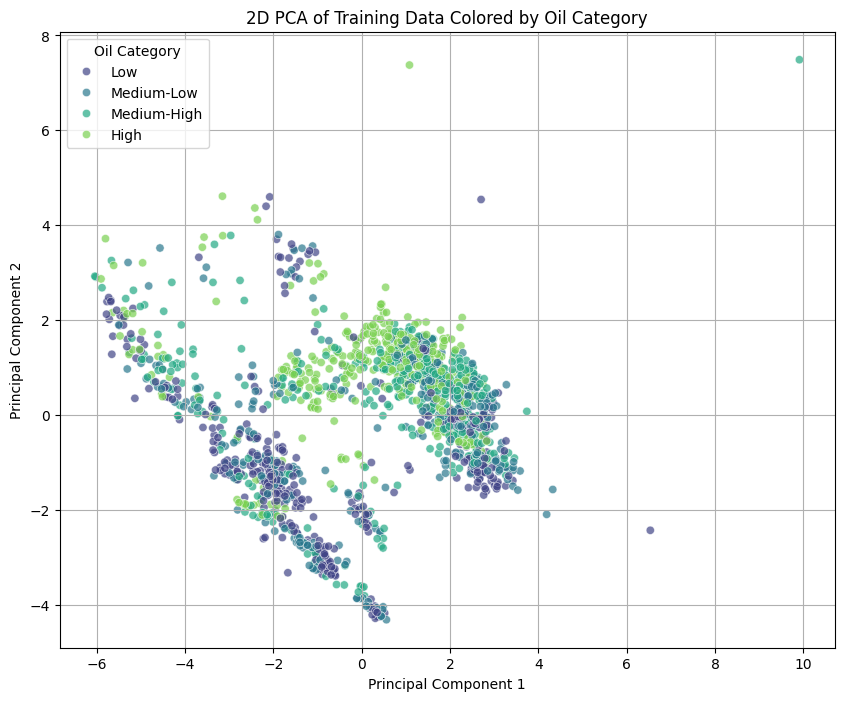

In [13]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# PCA with exactly 2 components
pca_2 = PCA(n_components=2)

# Scale the training data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)

# Fit on training data and transform
x_train_pca_2 = pca_2.fit_transform(x_train_scaled)

# Create DataFrame for plotting
pca_2_df = pd.DataFrame(
    data=x_train_pca_2,
    columns=['Principal Component 1', 'Principal Component 2']
)

# Add oil category column
pca_2_df['Oil Category'] = pd.qcut(
    y_train.reset_index(drop=True),
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

# Plot
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=pca_2_df,
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Oil Category',
    palette='viridis',
    alpha=0.7
)

plt.title('2D PCA of Training Data Colored by Oil Category')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)

plt.show()

In [14]:
# The 2D PCA projection reveals distinct regions in the feature space associated with different oil production levels. 
# High-producing wells cluster predominantly in the central region, while low-producing wells are more dispersed toward the outer regions. 
# The gradual overlap between categories suggests that the relationship between features and oil production is nonlinear 
# rather than sharply separable.

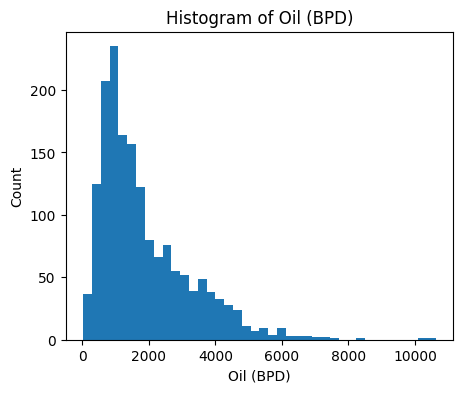

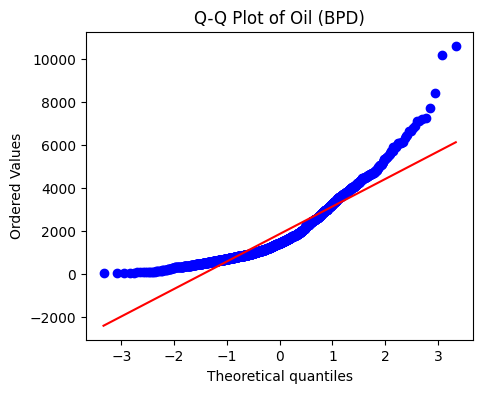

In [15]:
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.figure(figsize=(5,4))
plt.hist(y_train, bins=40)
plt.title("Histogram of Oil (BPD)")
plt.xlabel("Oil (BPD)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(5,4))
stats.probplot(y_train, dist="norm", plot=plt)
plt.title("Q-Q Plot of Oil (BPD)")
plt.show()

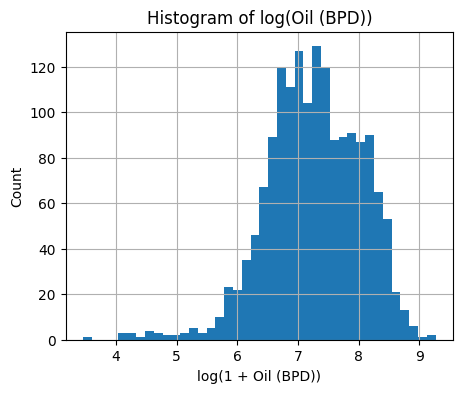

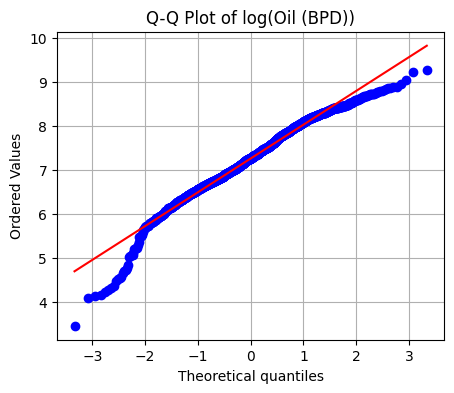

In [16]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

# Apply log transform
y_train_log = np.log1p(y_train)

# Histogram (log-transformed)

plt.figure(figsize=(5,4))
plt.hist(y_train_log, bins=40)
plt.title("Histogram of log(Oil (BPD))")
plt.xlabel("log(1 + Oil (BPD))")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Q-Q Plot (log-transformed)

plt.figure(figsize=(5,4))
stats.probplot(y_train_log, dist="norm", plot=plt)
plt.title("Q-Q Plot of log(Oil (BPD))")
plt.grid(True)
plt.show()

In [17]:
# A log transformation of the target variable was evaluated to address the strong right-skewness observed in oil production.
# The transformation improved the distribution toward normality and reduced relative error (MAPD).
# However, it increased absolute prediction error (RMSD) and introduced greater variability across cross-validation folds.
# Since the primary objective is accurate prediction in the original units (BPD), and non-linear models can inherently capture 
# such transformations, the non-transformed target variable was ultimately preferred.

In [18]:
# Preparing the test set

# Separate features and target from test set
x_test = df_test.drop(columns=['Oil (BPD)']).copy()
y_test = df_test['Oil (BPD)'].copy()

# Remove identifier columns
x_test = x_test.drop(columns=['ID', 'Well_ID'], errors='ignore')

print(x_test.shape)
print(y_test.shape)

(549, 19)
(549,)


Original number of features: 19
Reduced number of features (PCA components): 13
Total variance explained by 13 components: 0.9546


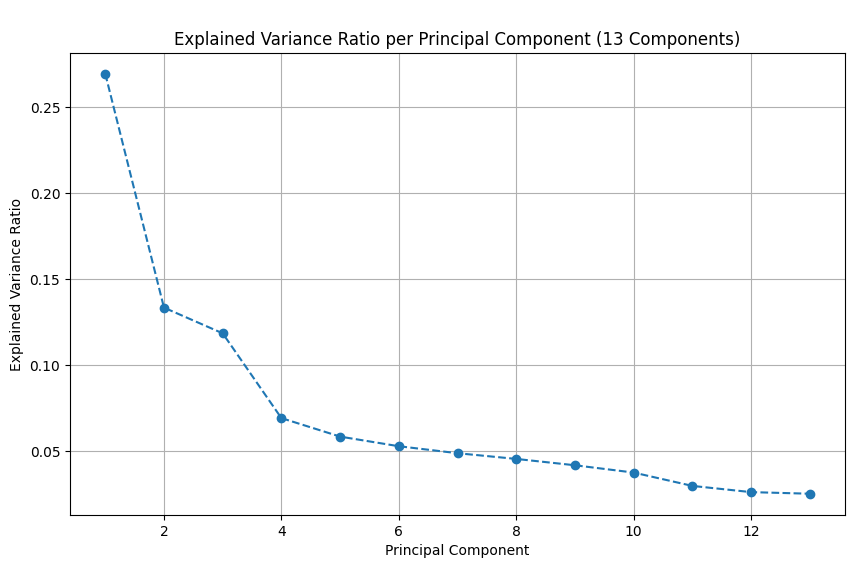

In [19]:
# PCA for Modeling

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Apply training medians to x_test
x_test[numerical_cols] = x_test[numerical_cols].fillna(train_medians)

# Scale the training and test data
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Perform PCA while retaining 95% of the total variance
pca = PCA(n_components=0.95)
x_train_pca = pca.fit_transform(x_train_scaled)
x_test_pca = pca.transform(x_test_scaled)

print(f"Original number of features: {x_train.shape[1]}")
print(f"Reduced number of features (PCA components): {pca.n_components_}")
print(f"Total variance explained by {pca.n_components_} components: {pca.explained_variance_ratio_.sum():.4f}")

# Plot the explained variance ratio
plt.figure(figsize=(10, 6))
plt.plot(
    range(1, pca.n_components_ + 1),
    pca.explained_variance_ratio_,
    marker='o',
    linestyle='--'
)
plt.title(f'\nExplained Variance Ratio per Principal Component ({pca.n_components_} Components)')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

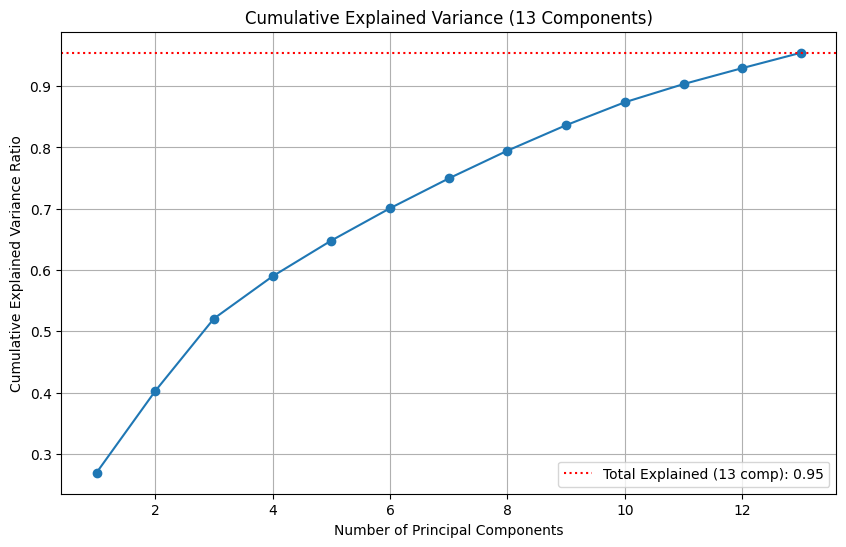

In [20]:
# Plot cumulative explained variance
cumulative_explained_variance = np.cumsum(pca.explained_variance_ratio_)
plt.figure(figsize=(10, 6))
plt.plot(range(1, pca.n_components_ + 1), cumulative_explained_variance, marker='o', linestyle='-')
plt.title(f'Cumulative Explained Variance ({pca.n_components_} Components)')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.axhline(y=pca.explained_variance_ratio_.sum(), color='r', linestyle=':', label=f'Total Explained ({pca.n_components_} comp): {pca.explained_variance_ratio_.sum():.2f}')
plt.grid(True)
plt.legend()
plt.show()

In [21]:
# Extract names of selected features by examining loadings
print(f"\nMost influential original features for each of the {pca.n_components_} Principal Components:")
for i, component in enumerate(pca.components_):
    # Sort features by absolute loading value
    sorted_loadings_idx = np.abs(component).argsort()[::-1]
    sorted_features = np.array(x_train.columns)[sorted_loadings_idx]
    sorted_values = component[sorted_loadings_idx]

    print(f"\nPrincipal Component {i+1}:")
    for j in range(5): # Display top 5 contributing features for each component
        print(f"  {sorted_features[j]}: {sorted_values[j]:.4f}")


Most influential original features for each of the 13 Principal Components:

Principal Component 1:
  header_psig: 0.3635
  sep_psig: 0.3619
  testline_psig: 0.3590
  choke_64: 0.3435
  sep_temp_F: 0.3128

Principal Component 2:
  fthp_psig: 0.3419
  testline_psig: 0.3184
  sep_psig: 0.3174
  fbhp_psia: 0.3019
  sbhp_psia: 0.3002

Principal Component 3:
  bsw_pct: 0.4561
  water_bpd: 0.4441
  flow_temp_F: 0.3832
  sbhp_psia: 0.3322
  fbhp_psia: 0.3074

Principal Component 4:
  orifice_inch: 0.4835
  gas_total_mmscfd: 0.4453
  annA_psig: 0.4391
  test_hrs: -0.3218
  fbhp_psia: -0.2744

Principal Component 5:
  annB_psig: 0.6875
  test_hrs: 0.5969
  annA_psig: 0.3117
  orifice_inch: 0.1810
  gas_total_mmscfd: 0.0876

Principal Component 6:
  gl_gas_mmscfd: 0.9734
  annA_psig: 0.2122
  api: 0.0414
  choke_64: -0.0377
  annB_psig: 0.0340

Principal Component 7:
  annA_psig: 0.6544
  api: 0.5919
  orifice_inch: -0.2613
  gas_total_mmscfd: -0.2020
  choke_64: -0.1935

Principal Component 8:

In [22]:
from sklearn.decomposition import KernelPCA

# Perform Kernel PCA with 8 components and an RBF kernel
# For KernelPCA, n_components should be less than or equal to the number of samples; I set it to 8.
kpca = KernelPCA(n_components=8, kernel="rbf", gamma=None, fit_inverse_transform=True, alpha=0.1, random_state=42)

x_train_kpca = kpca.fit_transform(x_train_scaled)
x_test_kpca = kpca.transform(x_test_scaled)

print(f"Original number of features: {x_train_scaled.shape[1]}")
print(f"Reduced number of features (Kernel PCA components): {kpca.n_components}")
print(f"Shape of transformed training data (x_train_kpca): {x_train_kpca.shape}")
print(f"Shape of transformed test data (x_test_kpca): {x_test_kpca.shape}")

Original number of features: 19
Reduced number of features (Kernel PCA components): 8
Shape of transformed training data (x_train_kpca): (1644, 8)
Shape of transformed test data (x_test_kpca): (549, 8)


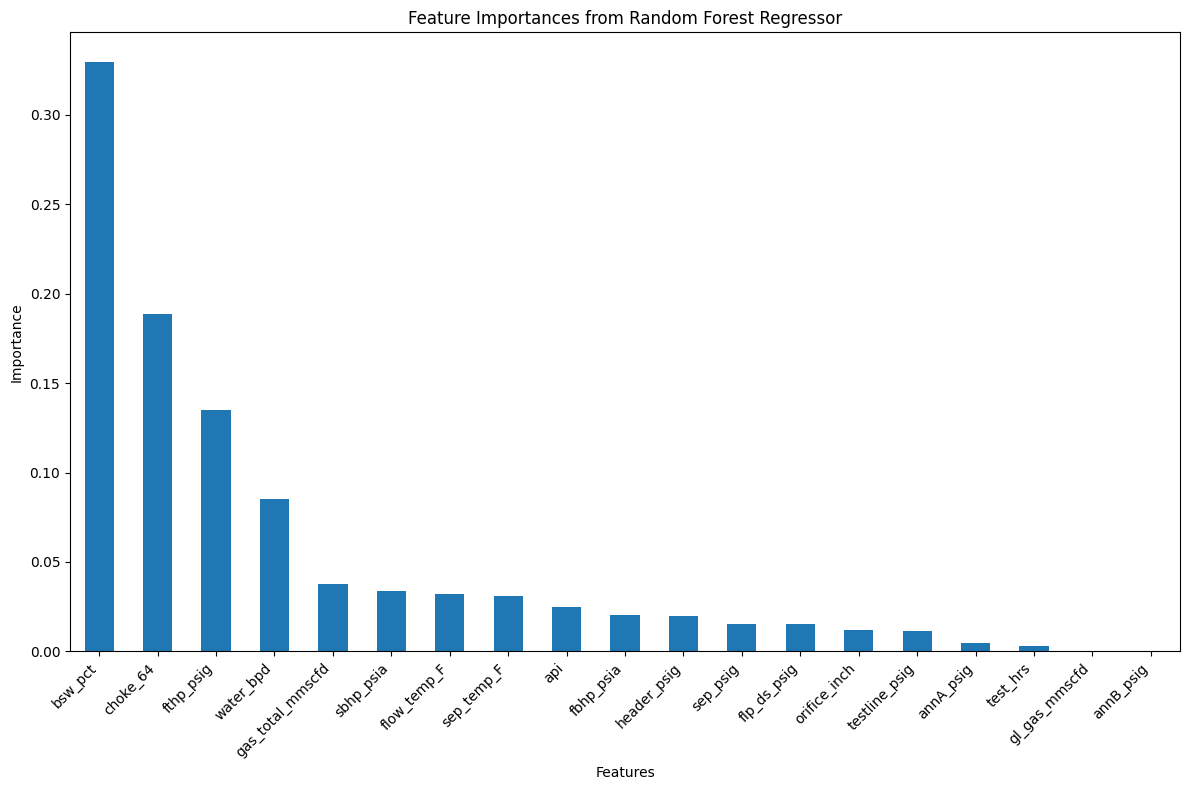

In [23]:
# Reducing dimensionality with RandomForestRegressor

from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import pandas as pd

# Initialize Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Train the model using training data
rf_model.fit(x_train, y_train)

# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a Pandas Series for visualization
feature_names = x_train.columns
importances_df = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)

# Plot all feature importances
plt.figure(figsize=(12, 8))
importances_df.plot(kind='bar')
plt.title('Feature Importances from Random Forest Regressor')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
print("\nTop 10 Most Important Features:")
print(importances_df.head(10))

top6_featuresRFR = importances_df.head(6).index.tolist()

print("\nTop 6 selected features (RFR):")
print(top6_featuresRFR)

# Create reduced training and test feature sets
x_train_top6RFR = x_train[top6_featuresRFR]
x_test_top6RFR = x_test[top6_featuresRFR]


Top 10 Most Important Features:
bsw_pct             0.329548
choke_64            0.188683
fthp_psig           0.134905
water_bpd           0.085040
gas_total_mmscfd    0.037602
sbhp_psia           0.033636
flow_temp_F         0.031977
sep_temp_F          0.030935
api                 0.024940
fbhp_psia           0.020259
dtype: float64

Top 6 selected features (RFR):
['bsw_pct', 'choke_64', 'fthp_psig', 'water_bpd', 'gas_total_mmscfd', 'sbhp_psia']


In [25]:
# Feature importance analysis using Random Forest revealed that a small subset of variables 
# (notably bsw_pct, choke_64, fthp_psig, and water_bpd) dominate prediction. 
# This suggests that the model can be simplified without significant loss in performance.

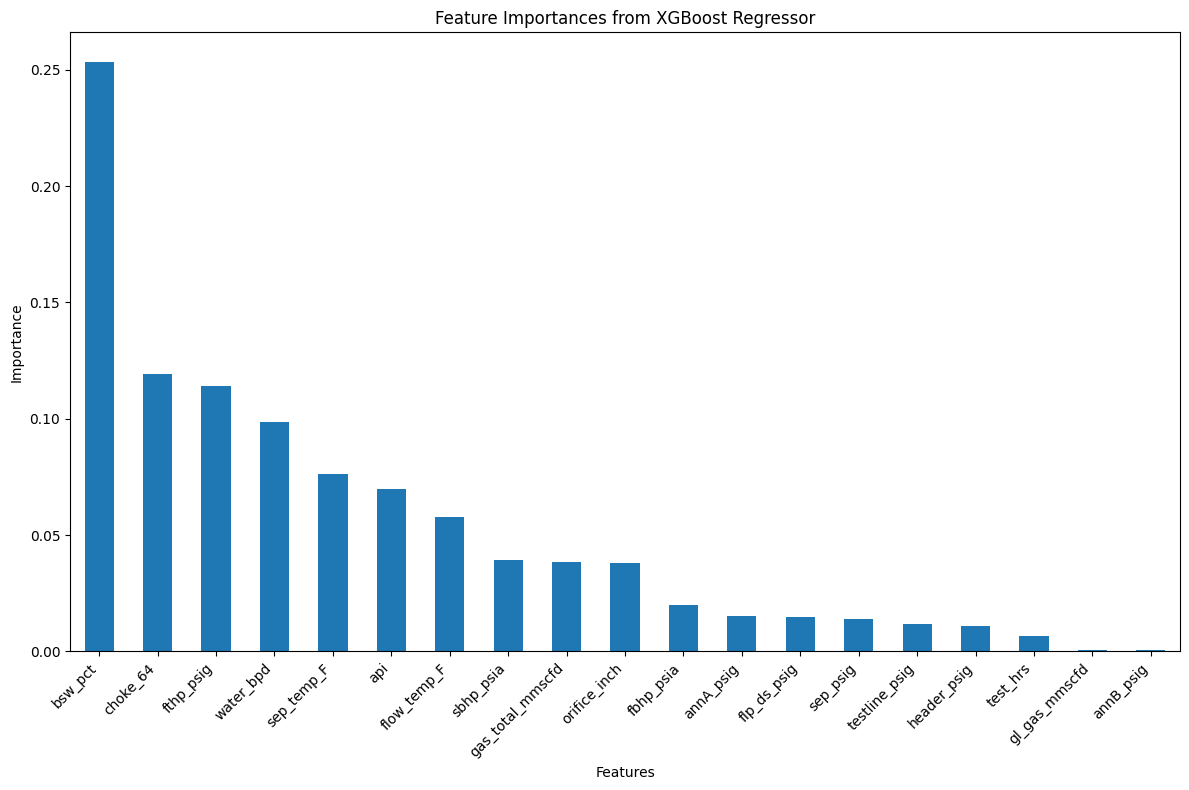

In [26]:
# !pip install xgboost
import xgboost as xgb
import matplotlib.pyplot as plt
import pandas as pd

# Initialize the XGBoost Regressor model
xgb_model = xgb.XGBRegressor(random_state=42)

# Train the model on the training data
xgb_model.fit(x_train, y_train)

# Get feature importances
feature_importances = xgb_model.feature_importances_

# Create Pandas Series
feature_names = x_train.columns
importances_df = pd.Series(feature_importances, index=feature_names).sort_values(ascending=False)

# Plot
plt.figure(figsize=(12, 8))
importances_df.plot(kind='bar')
plt.title('Feature Importances from XGBoost Regressor')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [27]:
# Print head
print("\nTop 10 Most Important Features (XGBoost):")
print(importances_df.head(10))

top10_featuresXGR = importances_df.head(10).index.tolist()

print("\nTop 10 selected features (XGB):")
print(top10_featuresXGR)

# Create reduced training and test feature sets
x_train_top10XGR = x_train[top10_featuresXGR]
x_test_top10XGR = x_test[top10_featuresXGR]


Top 10 Most Important Features (XGBoost):
bsw_pct             0.253427
choke_64            0.119297
fthp_psig           0.114157
water_bpd           0.098663
sep_temp_F          0.076360
api                 0.069747
flow_temp_F         0.057657
sbhp_psia           0.039408
gas_total_mmscfd    0.038441
orifice_inch        0.038133
dtype: float32

Top 10 selected features (XGB):
['bsw_pct', 'choke_64', 'fthp_psig', 'water_bpd', 'sep_temp_F', 'api', 'flow_temp_F', 'sbhp_psia', 'gas_total_mmscfd', 'orifice_inch']


In [28]:
# Both Random Forest and XGBoost regressors consistently identified bsw_pct, fthp_psig, water_bpd, and choke_64 as the most influential 
# features. This agreement confirms the robustness of feature importance and highlights the dominant role of these variables in predicting 
# oil production in alignment with established knowledge.

In [29]:
from sklearn.preprocessing import StandardScaler

# Scale the feature subset selected by XGBoost Regressor
scaler_top10XGR = StandardScaler()
x_train_top10XGR_scaled = scaler_top10XGR.fit_transform(x_train_top10XGR)
x_test_top10XGR_scaled = scaler_top10XGR.transform(x_test_top10XGR)

# Scale the feature subset selected by Random Forest Regressor
scaler_top6RFR = StandardScaler()
x_train_top6RFR_scaled = scaler_top6RFR.fit_transform(x_train_top6RFR)
x_test_top6RFR_scaled = scaler_top6RFR.transform(x_test_top6RFR)

In [30]:
# Import models

# !pip install catboost
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor

# Define models
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVM (RBF)": SVR(kernel='rbf'),
    "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    "Random Forest": RandomForestRegressor(random_state=42),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

# Organize all data kinds
data_kinds = {
    "Raw": {
        "scaled_train": x_train_scaled,
        "scaled_test": x_test_scaled,
        "unscaled_train": x_train,
        "unscaled_test": x_test
    },
    "PCA": {
        "scaled_train": x_train_pca,
        "scaled_test": x_test_pca,
        "unscaled_train": x_train_pca,
        "unscaled_test": x_test_pca
    },
    "KPCA": {
        "scaled_train": x_train_kpca,
        "scaled_test": x_test_kpca,
        "unscaled_train": x_train_kpca,
        "unscaled_test": x_test_kpca
    },
    "Top10XGR": {
        "scaled_train": x_train_top10XGR_scaled,
        "scaled_test": x_test_top10XGR_scaled,
        "unscaled_train": x_train_top10XGR,
        "unscaled_test": x_test_top10XGR
    },
    "Top6RFR": {
        "scaled_train": x_train_top6RFR_scaled,
        "scaled_test": x_test_top6RFR_scaled,
        "unscaled_train": x_train_top6RFR,
        "unscaled_test": x_test_top6RFR
    }
}

# Models that require scaled inputs
scaled_models = {
    "KNN": models["KNN"],
    "SVM (RBF)": models["SVM (RBF)"]
}

# Models that can work directly on unscaled inputs
unscaled_models = {
    "Decision Tree": models["Decision Tree"],
    "Random Forest": models["Random Forest"],
    "XGBoost": models["XGBoost"],
    "CatBoost": models["CatBoost"]
}

In [87]:
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# This block evaluates the training performance of all model–data combinations
# across both scaled and unscaled feature sets. Each model is cloned to ensure
# independence and prevent data leakage across iterations. Predictions are made
# on the training data to compute baseline performance metrics including R2,
# RMSE, MAE, MAPD, and STBD. These metrics quantify goodness of fit, absolute
# and relative error, and the consistency of residuals. The results are stored
# and sorted to provide an initial ranking of model behavior before cross-validation.

def mapd_score(y_true, y_pred):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    eps = 1e-10
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def stbd_score(y_true, y_pred):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    residuals = y_true - y_pred
    return np.std(residuals, ddof=1)

train_results = []

for kind_name, kind_data in data_kinds.items():

    for model_name, model in scaled_models.items():
        x_train_model = np.array(kind_data["scaled_train"])
        y_train_model = np.array(y_train).ravel()

        model_fit = clone(model)
        model_fit.fit(x_train_model, y_train_model)

        y_train_pred = model_fit.predict(x_train_model)

        train_results.append({
            "Data_Kind": kind_name,
            "Model": model_name,
            "R2": r2_score(y_train_model, y_train_pred),
            "RMSE": np.sqrt(mean_squared_error(y_train_model, y_train_pred)),
            "MAE": mean_absolute_error(y_train_model, y_train_pred),
            "MAPD": mapd_score(y_train_model, y_train_pred),
            "STBD": stbd_score(y_train_model, y_train_pred)
        })

    for model_name, model in unscaled_models.items():
        x_train_model = np.array(kind_data["unscaled_train"])
        y_train_model = np.array(y_train).ravel()

        model_fit = clone(model)
        model_fit.fit(x_train_model, y_train_model)

        y_train_pred = model_fit.predict(x_train_model)

        train_results.append({
            "Data_Kind": kind_name,
            "Model": model_name,
            "R2": r2_score(y_train_model, y_train_pred),
            "RMSE": np.sqrt(mean_squared_error(y_train_model, y_train_pred)),
            "MAE": mean_absolute_error(y_train_model, y_train_pred),
            "MAPD": mapd_score(y_train_model, y_train_pred),
            "STBD": stbd_score(y_train_model, y_train_pred)
        })

train_results_df = pd.DataFrame(train_results)

print("Training set performance results:")
display(
    train_results_df.sort_values(
        by=["RMSE", "MAE", "MAPD", "STBD", "R2"],
        ascending=[True, True, True, True, False]
    )
)

Training set performance results:


,Data_Kind,Model,R2,RMSE,MAE,MAPD,STBD
2,Raw,Decision Tree,1.000000,0.000000,0.000000,0.000000,0.000000
8,PCA,Decision Tree,1.000000,0.000000,0.000000,0.000000,0.000000
20,Top10XGR,Decision Tree,1.000000,0.000000,0.000000,0.000000,0.000000
26,Top6RFR,Decision Tree,1.000000,0.662701,0.023114,0.000377,0.662903
14,KPCA,Decision Tree,0.999785,20.052577,0.833435,0.071426,20.058679
10,PCA,XGBoost,0.999222,38.095230,27.077925,2.355626,38.106821
22,Top10XGR,XGBoost,0.998840,46.523527,31.110827,2.300821,46.537679
4,Raw,XGBoost,0.998812,47.092070,32.660686,2.680477,47.106390
28,Top6RFR,XGBoost,0.998793,47.459284,32.495658,2.371462,47.473709
16,KPCA,XGBoost,0.994643,99.980514,69.470136,6.709822,100.010934


In [32]:
# The Decision Tree models exhibit severe overfitting, achieving near-perfect performance on the training set,
# which indicates memorization rather than generalization.
# XGBoost also shows very high performance with slight signs of overfitting.
# In contrast, Random Forest and CatBoost display more balanced behavior and are likely to generalize better.
# KNN underfits the data, while SVM performs poorly and fails to capture the underlying relationships.

In [33]:
from sklearn.model_selection import KFold
from sklearn.base import clone
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

# This block performs 10-fold cross-validation across all model–data combinations
# to evaluate generalization performance on the training set. For each fold, models
# are trained on a subset of the data and validated on unseen partitions, with
# predictions aggregated to form a full out-of-fold estimate. Performance is
# quantified using R2, RMSE, MAE, MAPD, and STBD, along with their mean and
# standard deviation across folds to assess both accuracy and stability. The
# results are then sorted to provide a robust baseline ranking of models prior
# to final tuning and testing.

def mapd_score(y_true, y_pred):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    eps = 1e-10
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def stbd_score(y_true, y_pred):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    residuals = y_true - y_pred
    return np.std(residuals, ddof=1)

kf = KFold(n_splits=10, shuffle=True, random_state=42)

results = []

for kind_name, kind_data in data_kinds.items():

    for model_name, model in scaled_models.items():
        x_train_model = np.array(kind_data["scaled_train"])
        y_train_model = np.array(y_train).ravel()

        y_train_cv_pred = np.zeros(len(y_train_model))

        fold_r2 = []
        fold_mae = []
        fold_rmse = []
        fold_mapd = []
        fold_stbd = []

        for train_idx, val_idx in kf.split(x_train_model):
            x_tr, x_val = x_train_model[train_idx], x_train_model[val_idx]
            y_tr, y_val = y_train_model[train_idx], y_train_model[val_idx]

            model_cv = clone(model)
            model_cv.fit(x_tr, y_tr)

            y_val_pred = model_cv.predict(x_val)
            y_train_cv_pred[val_idx] = y_val_pred

            fold_r2.append(r2_score(y_val, y_val_pred))
            fold_mae.append(mean_absolute_error(y_val, y_val_pred))
            fold_rmse.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
            fold_mapd.append(mapd_score(y_val, y_val_pred))
            fold_stbd.append(stbd_score(y_val, y_val_pred))

        results.append({
            "Data_Kind": kind_name,
            "Model": model_name,
            "R2": r2_score(y_train_model, y_train_cv_pred),
            "MAE": mean_absolute_error(y_train_model, y_train_cv_pred),
            "RMSE": np.sqrt(mean_squared_error(y_train_model, y_train_cv_pred)),
            "MAPD": mapd_score(y_train_model, y_train_cv_pred),
            "STBD": stbd_score(y_train_model, y_train_cv_pred),
            "R2_mean": np.mean(fold_r2),
            "R2_std": np.std(fold_r2),
            "MAE_mean": np.mean(fold_mae),
            "MAE_std": np.std(fold_mae),
            "RMSE_mean": np.mean(fold_rmse),
            "RMSE_std": np.std(fold_rmse),
            "MAPD_mean": np.mean(fold_mapd),
            "MAPD_std": np.std(fold_mapd),
            "STBD_mean": np.mean(fold_stbd),
            "STBD_std": np.std(fold_stbd)
        })

    for model_name, model in unscaled_models.items():
        x_train_model = np.array(kind_data["unscaled_train"])
        y_train_model = np.array(y_train).ravel()

        y_train_cv_pred = np.zeros(len(y_train_model))

        fold_r2 = []
        fold_mae = []
        fold_rmse = []
        fold_mapd = []
        fold_stbd = []

        for train_idx, val_idx in kf.split(x_train_model):
            x_tr, x_val = x_train_model[train_idx], x_train_model[val_idx]
            y_tr, y_val = y_train_model[train_idx], y_train_model[val_idx]

            model_cv = clone(model)
            model_cv.fit(x_tr, y_tr)

            y_val_pred = model_cv.predict(x_val)
            y_train_cv_pred[val_idx] = y_val_pred

            fold_r2.append(r2_score(y_val, y_val_pred))
            fold_mae.append(mean_absolute_error(y_val, y_val_pred))
            fold_rmse.append(np.sqrt(mean_squared_error(y_val, y_val_pred)))
            fold_mapd.append(mapd_score(y_val, y_val_pred))
            fold_stbd.append(stbd_score(y_val, y_val_pred))

        results.append({
            "Data_Kind": kind_name,
            "Model": model_name,
            "R2": r2_score(y_train_model, y_train_cv_pred),
            "MAE": mean_absolute_error(y_train_model, y_train_cv_pred),
            "RMSE": np.sqrt(mean_squared_error(y_train_model, y_train_cv_pred)),
            "MAPD": mapd_score(y_train_model, y_train_cv_pred),
            "STBD": stbd_score(y_train_model, y_train_cv_pred),
            "R2_mean": np.mean(fold_r2),
            "R2_std": np.std(fold_r2),
            "MAE_mean": np.mean(fold_mae),
            "MAE_std": np.std(fold_mae),
            "RMSE_mean": np.mean(fold_rmse),
            "RMSE_std": np.std(fold_rmse),
            "MAPD_mean": np.mean(fold_mapd),
            "MAPD_std": np.std(fold_mapd),
            "STBD_mean": np.mean(fold_stbd),
            "STBD_std": np.std(fold_stbd)
        })

results_df = pd.DataFrame(results)

cv_display_df = results_df[[
    "Data_Kind",
    "Model",
    "R2_mean", "R2_std",
    "MAE_mean", "MAE_std",
    "RMSE_mean", "RMSE_std",
    "MAPD_mean", "MAPD_std",
    "STBD_mean", "STBD_std"
]]

cv_display_df_sorted = cv_display_df.sort_values(
    by=["RMSE_mean", "R2_mean", "MAPD_mean", "MAE_mean", "STBD_mean"],
    ascending=[True, False, True, True, True]
)

print("10 fold cross validation results on the training set only:")
display(cv_display_df_sorted)

10 fold cross validation results on the training set only:


,Data_Kind,Model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MAPD_mean,MAPD_std,STBD_mean,STBD_std
29,Top6RFR,CatBoost,0.901746,0.053024,215.683047,28.373581,419.878010,143.817661,15.805135,3.325420,419.610507,142.453480
23,Top10XGR,CatBoost,0.899923,0.052611,227.758442,26.055740,422.875950,141.821908,17.151119,4.385432,421.757503,139.597897
5,Raw,CatBoost,0.899129,0.051864,231.697647,24.703148,425.872148,140.628443,17.523922,3.656857,425.036386,138.864164
28,Top6RFR,XGBoost,0.885942,0.050752,235.553548,30.275307,455.254197,137.955674,16.639470,4.119145,454.908307,136.459186
21,Top10XGR,Random Forest,0.884018,0.053898,231.656747,29.242198,457.643516,141.024308,15.954301,1.893704,457.383564,140.225831
27,Top6RFR,Random Forest,0.883626,0.050558,224.466193,29.955431,459.520196,136.236737,14.780192,2.541026,459.512179,135.668797
22,Top10XGR,XGBoost,0.881694,0.052530,245.253228,28.275042,462.210331,137.909104,18.375625,4.711475,462.192312,136.454988
4,Raw,XGBoost,0.876976,0.049797,253.797570,30.809389,470.982914,131.186219,19.562802,5.577121,470.964143,130.171234
3,Raw,Random Forest,0.878083,0.046814,238.445321,23.272804,471.161494,127.780189,17.028912,2.494563,470.882480,127.213214
26,Top6RFR,Decision Tree,0.802875,0.059829,287.224120,40.177985,599.200714,140.124746,17.914273,4.303452,599.481273,140.417811


In [34]:
top_candidates = cv_display_df_sorted.head(8)
print("Top candidate models based on CV ranking:")
display(top_candidates)

Top candidate models based on CV ranking:


,Data_Kind,Model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MAPD_mean,MAPD_std,STBD_mean,STBD_std
29,Top6RFR,CatBoost,0.901746,0.053024,215.683047,28.373581,419.878010,143.817661,15.805135,3.325420,419.610507,142.453480
23,Top10XGR,CatBoost,0.899923,0.052611,227.758442,26.055740,422.875950,141.821908,17.151119,4.385432,421.757503,139.597897
5,Raw,CatBoost,0.899129,0.051864,231.697647,24.703148,425.872148,140.628443,17.523922,3.656857,425.036386,138.864164
28,Top6RFR,XGBoost,0.885942,0.050752,235.553548,30.275307,455.254197,137.955674,16.639470,4.119145,454.908307,136.459186
21,Top10XGR,Random Forest,0.884018,0.053898,231.656747,29.242198,457.643516,141.024308,15.954301,1.893704,457.383564,140.225831
27,Top6RFR,Random Forest,0.883626,0.050558,224.466193,29.955431,459.520196,136.236737,14.780192,2.541026,459.512179,135.668797
22,Top10XGR,XGBoost,0.881694,0.052530,245.253228,28.275042,462.210331,137.909104,18.375625,4.711475,462.192312,136.454988
4,Raw,XGBoost,0.876976,0.049797,253.797570,30.809389,470.982914,131.186219,19.562802,5.577121,470.964143,130.171234


In [35]:
# This block compares training performance with cross-validation results to quantify
# generalization behavior for each model–data combination. The training metrics are
# merged with cross-validation mean metrics, and performance gaps are computed to
# measure the extent of overfitting or underfitting. Larger gaps indicate poorer
# generalization, while smaller gaps suggest more stable models. The results are
# sorted to highlight models with the highest generalization discrepancies for
# further diagnostic analysis.

# Merge training and CV results
merged_df = pd.merge(
    train_results_df,
    results_df,
    on=["Data_Kind", "Model"],
    suffixes=("_train", "_cv")
)

# Compute gaps using training metrics and CV mean metrics
merged_df["R2_gap"] = merged_df["R2_train"] - merged_df["R2_mean"]
merged_df["RMSE_gap"] = merged_df["RMSE_mean"] - merged_df["RMSE_train"]
merged_df["MAE_gap"] = merged_df["MAE_mean"] - merged_df["MAE_train"]
merged_df["MAPD_gap"] = merged_df["MAPD_mean"] - merged_df["MAPD_train"]
merged_df["STBD_gap"] = merged_df["STBD_mean"] - merged_df["STBD_train"]

# Display only gaps
gap_only_df = merged_df[[
    "Data_Kind",
    "Model",
    "R2_gap",
    "RMSE_gap",
    "MAE_gap",
    "MAPD_gap",
    "STBD_gap"
]]

# Sort by largest generalization gap
gap_only_df = gap_only_df.sort_values(
    by=["RMSE_gap", "MAE_gap", "R2_gap", "MAPD_gap", "STBD_gap"],
    ascending=[False, False, False, False, False]
)

print("Generalization gaps only (largest → smallest):")
display(gap_only_df)

Generalization gaps only (largest → smallest):


,Data_Kind,Model,R2_gap,RMSE_gap,MAE_gap,MAPD_gap,STBD_gap
8,PCA,Decision Tree,0.603429,1031.379655,597.833041,54.599490,1032.446959
14,KPCA,Decision Tree,0.536368,966.036710,577.517847,44.634392,965.846034
20,Top10XGR,Decision Tree,0.338538,761.579084,342.459850,23.632053,761.539364
2,Raw,Decision Tree,0.255521,680.831020,338.948242,22.439995,679.343039
10,PCA,XGBoost,0.253411,641.465835,403.817020,36.880260,641.002508
16,KPCA,XGBoost,0.291337,635.112394,391.258710,35.104898,635.381048
26,Top6RFR,Decision Tree,0.197125,598.538013,287.201006,17.913896,598.818371
15,KPCA,Random Forest,0.231465,442.280573,273.126990,27.301764,442.066185
9,PCA,Random Forest,0.226862,433.211817,271.079851,28.872073,432.780651
4,Raw,XGBoost,0.121835,423.890844,221.136884,16.882325,423.857754


In [36]:
# Models with large generalization gaps (e.g., Decision Trees and PCA-based models) exhibit strong overfitting. 
# Models such as SVM show very small gaps but poor performance, indicating underfitting. 
# Models like CatBoost, Random Forest, and XGBoost show moderate gaps with strong performance, 
# indicating a good balance between bias and variance.

In [37]:
# Learning curves plotted after initial CV evaluation to diagnose overfitting and underfitting

from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.base import clone
import numpy as np
import matplotlib.pyplot as plt

# This block generates RMSE-based learning curves after the initial cross-validation
# screening. The curves compare training and validation error as the training set
# size increases, helping diagnose overfitting, underfitting, and model stability.
# The shaded regions show variability across folds, while the gap between training
# and validation RMSE indicates the model’s generalization behavior.

# Define RMSE scorer for learning curve
rmse_scorer = make_scorer(
    lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
    greater_is_better=False
)

def plot_learning_curve_rmse(model, x_data, y_data, title):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=clone(model),
        X=np.array(x_data),
        y=np.array(y_data).ravel(),
        cv=10,
        scoring=rmse_scorer,
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    train_rmse_mean = -np.mean(train_scores, axis=1)
    train_rmse_std = np.std(train_scores, axis=1)

    val_rmse_mean = -np.mean(val_scores, axis=1)
    val_rmse_std = np.std(val_scores, axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_rmse_mean, marker='o', label='Training RMSE')
    plt.plot(train_sizes, val_rmse_mean, marker='o', label='Validation RMSE')

    plt.fill_between(
        train_sizes,
        train_rmse_mean - train_rmse_std,
        train_rmse_mean + train_rmse_std,
        alpha=0.2
    )

    plt.fill_between(
        train_sizes,
        val_rmse_mean - val_rmse_std,
        val_rmse_mean + val_rmse_std,
        alpha=0.2
    )

    plt.title(title)
    plt.xlabel('Training Set Size')
    plt.ylabel('RMSE')
    plt.grid(True)
    plt.legend()
    plt.show()

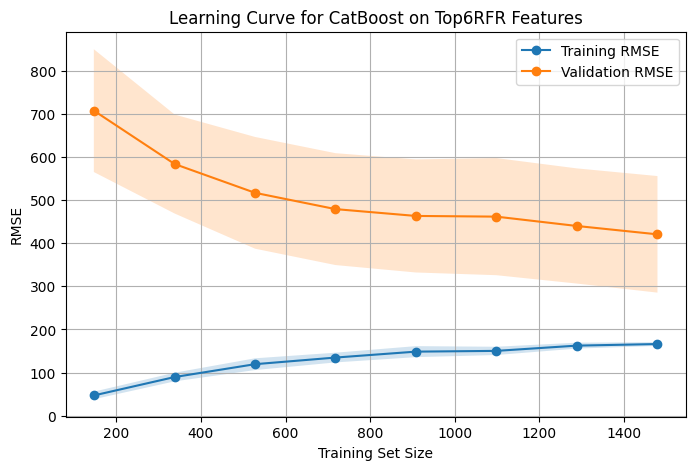

In [38]:
plot_learning_curve_rmse(
    models["CatBoost"],
    x_train_top6RFR,
    y_train,
    "Learning Curve for CatBoost on Top6RFR Features"
)

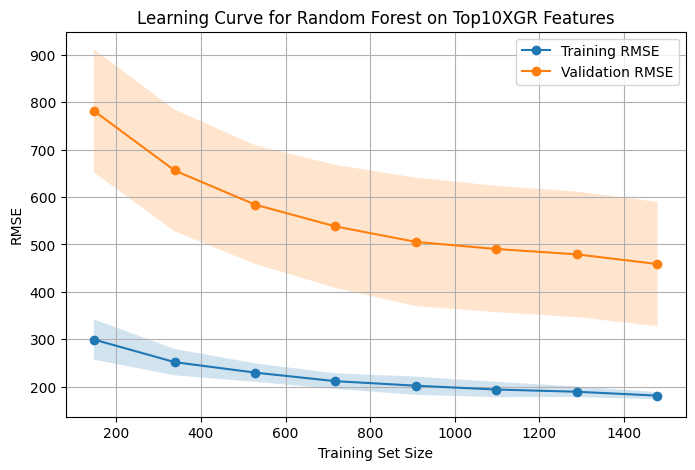

In [39]:
plot_learning_curve_rmse(
    models["Random Forest"],
    x_train_top10XGR,
    y_train,
    "Learning Curve for Random Forest on Top10XGR Features"
)

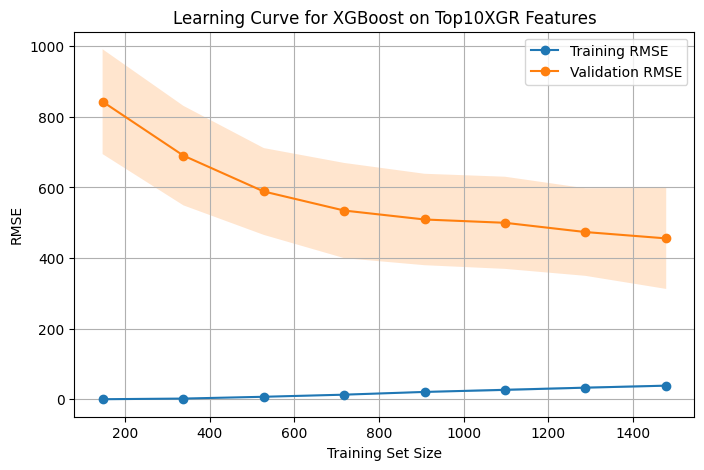

In [40]:
plot_learning_curve_rmse(
    models["XGBoost"],
    x_train_top10XGR,
    y_train,
    "Learning Curve for XGBoost on Top10XGR Features"
)

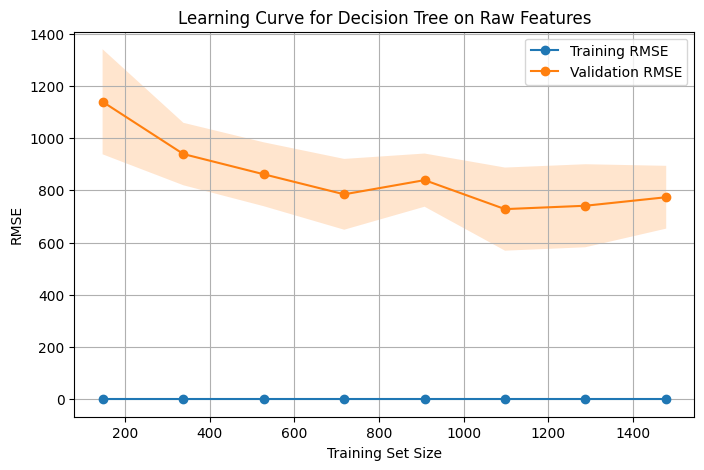

In [41]:
plot_learning_curve_rmse(
    models["Decision Tree"],
    x_train,
    y_train,
    "Learning Curve for Decision Tree on Raw Features"
)

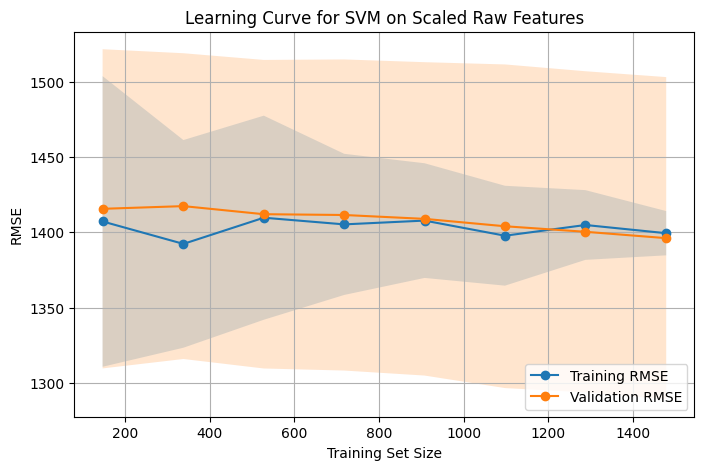

In [42]:
plot_learning_curve_rmse(
    models["SVM (RBF)"],
    x_train_scaled,
    y_train,
    "Learning Curve for SVM on Scaled Raw Features"
)

In [43]:
# Learning Curve Interpretation Summary:
# CatBoost shows controlled overfitting with improving generalization as data increases.
# XGBoost exhibits stronger overfitting than CatBoost (very low training error, high validation error) but benefits from more data.
# Random Forest demonstrates the best balance, with steadily decreasing validation error and a moderate, stable gap.
# Decision Tree severely overfits, with near-zero training error and poor validation performance.
# SVM underfits, as both training and validation errors are high and nearly identical with no improvement.

In [46]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.base import clone

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# This block performs nested cross-validation on the shortlisted model–data
# combinations to obtain an unbiased estimate of generalization performance
# while simultaneously tuning hyperparameters. The inner loop (GridSearchCV)
# selects optimal hyperparameters, while the outer loop evaluates model
# performance on unseen data. For boosting models, early stopping is applied
# using a validation split within each fold. Performance is quantified using
# R2, RMSE, MAE, MAPD, and STBD, with mean and standard deviation used to
# assess both accuracy and stability. The best parameters from each fold are
# also recorded to analyze consistency across splits.

def mapd_score(y_true, y_pred):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    eps = 1e-10
    return np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100

def stbd_score(y_true, y_pred):
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    residuals = y_true - y_pred
    return np.std(residuals, ddof=1)

shortlist = [
    {"tag": "t6rfr_cat",   "data_kind": "Top6RFR",  "model_name": "CatBoost",      "input_type": "unscaled"},
    {"tag": "t10xgr_cat",  "data_kind": "Top10XGR", "model_name": "CatBoost",      "input_type": "unscaled"},
    {"tag": "raw_cat",     "data_kind": "Raw",      "model_name": "CatBoost",      "input_type": "unscaled"},
    {"tag": "t6rfr_xgb",   "data_kind": "Top6RFR",  "model_name": "XGBoost",       "input_type": "unscaled"},
    {"tag": "t10xgr_xgb",  "data_kind": "Top10XGR", "model_name": "XGBoost",       "input_type": "unscaled"},
    {"tag": "raw_xgb",     "data_kind": "Raw",      "model_name": "XGBoost",       "input_type": "unscaled"},
    {"tag": "t10xgr_rf",   "data_kind": "Top10XGR", "model_name": "Random Forest", "input_type": "unscaled"},
    {"tag": "t6rfr_rf",    "data_kind": "Top6RFR",  "model_name": "Random Forest", "input_type": "unscaled"}
]

model_dict = {
    "CatBoost": CatBoostRegressor(
        random_state=42,
        verbose=0,
        loss_function="RMSE"
    ),
    "XGBoost": XGBRegressor(
        random_state=42,
        verbosity=0,
        objective="reg:squarederror",
        early_stopping_rounds=50
    ),
    "Random Forest": RandomForestRegressor(
        random_state=42
    )
}

param_grids = {
    "CatBoost": {
        "iterations": [5000],
        "depth": [4, 6, 8],
        "learning_rate": [0.03, 0.05, 0.1],
        "l2_leaf_reg": [3, 5, 7]
    },
    "XGBoost": {
        "n_estimators": [5000],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.03, 0.05, 0.1],
        "subsample": [0.8, 1.0],
        "colsample_bytree": [0.8, 1.0]
    },
    "Random Forest": {
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2]
    }
}

outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

nested_results = []
nested_best_params = {}

for item in shortlist:
    tag = item["tag"]
    data_kind = item["data_kind"]
    model_name = item["model_name"]
    input_type = item["input_type"]

    x_data = np.array(data_kinds[data_kind][f"{input_type}_train"])
    y_data = np.array(y_train).ravel()

    fold_r2 = []
    fold_mae = []
    fold_rmse = []
    fold_mapd = []
    fold_stbd = []
    fold_best_params = []

    print(f"\nRunning nested CV for {tag} on {data_kind} using {model_name}...")

    for outer_fold, (train_idx, test_idx) in enumerate(outer_cv.split(x_data), start=1):
        x_outer_train, x_outer_test = x_data[train_idx], x_data[test_idx]
        y_outer_train, y_outer_test = y_data[train_idx], y_data[test_idx]

        fit_params = {}

        if model_name in ["CatBoost", "XGBoost"]:
            x_train_inner, x_val_inner, y_train_inner, y_val_inner = train_test_split(
                x_outer_train,
                y_outer_train,
                test_size=0.1,
                random_state=42
            )

            x_grid_train = x_train_inner
            y_grid_train = y_train_inner

            if model_name == "CatBoost":
                fit_params = {
                    "eval_set": (x_val_inner, y_val_inner),
                    "early_stopping_rounds": 50
                }

            elif model_name == "XGBoost":
                fit_params = {
                    "eval_set": [(x_val_inner, y_val_inner)],
                    "verbose": False
                }

        else:
            x_grid_train = x_outer_train
            y_grid_train = y_outer_train

        grid = GridSearchCV(
            estimator=clone(model_dict[model_name]),
            param_grid=param_grids[model_name],
            scoring="neg_mean_squared_error",
            cv=inner_cv,
            n_jobs=-1,
            refit=True,
            verbose=0
        )

        grid.fit(x_grid_train, y_grid_train, **fit_params)

        best_model = grid.best_estimator_
        y_outer_pred = best_model.predict(x_outer_test)

        fold_r2.append(r2_score(y_outer_test, y_outer_pred))
        fold_mae.append(mean_absolute_error(y_outer_test, y_outer_pred))
        fold_rmse.append(np.sqrt(mean_squared_error(y_outer_test, y_outer_pred)))
        fold_mapd.append(mapd_score(y_outer_test, y_outer_pred))
        fold_stbd.append(stbd_score(y_outer_test, y_outer_pred))
        fold_best_params.append(grid.best_params_)

    nested_best_params[tag] = fold_best_params

    nested_results.append({
        "tag": tag,
        "Data_Kind": data_kind,
        "Model": model_name,
        "R2_mean": np.mean(fold_r2),
        "R2_std": np.std(fold_r2),
        "MAE_mean": np.mean(fold_mae),
        "MAE_std": np.std(fold_mae),
        "RMSE_mean": np.mean(fold_rmse),
        "RMSE_std": np.std(fold_rmse),
        "MAPD_mean": np.mean(fold_mapd),
        "MAPD_std": np.std(fold_mapd),
        "STBD_mean": np.mean(fold_stbd),
        "STBD_std": np.std(fold_stbd),
        "Best_Params_by_Fold": fold_best_params
    })

nested_results_df = pd.DataFrame(nested_results)

nested_results_df = nested_results_df.sort_values(
    by=["RMSE_mean", "R2_mean", "MAPD_mean", "MAE_mean", "STBD_mean"],
    ascending=[True, False, True, True, True]
).reset_index(drop=True)

print("\nNested CV results for shortlisted models:")
display(nested_results_df)


Running nested CV for t6rfr_cat on Top6RFR using CatBoost...

Running nested CV for t10xgr_cat on Top10XGR using CatBoost...

Running nested CV for raw_cat on Raw using CatBoost...

Running nested CV for t6rfr_xgb on Top6RFR using XGBoost...

Running nested CV for t10xgr_xgb on Top10XGR using XGBoost...

Running nested CV for raw_xgb on Raw using XGBoost...

Running nested CV for t10xgr_rf on Top10XGR using Random Forest...

Running nested CV for t6rfr_rf on Top6RFR using Random Forest...
Nested CV results for shortlisted models:


,tag,Data_Kind,Model,R2_mean,R2_std,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MAPD_mean,MAPD_std,STBD_mean,STBD_std,Best_Params_by_Fold
0,raw_xgb,Raw,XGBoost,0.891965,0.040641,228.693425,13.482321,443.613814,103.436359,16.927997,3.342722,444.004708,103.375432,"[{'colsample_bytree': 0.8, 'learning_rate': 0...."
1,t6rfr_cat,Top6RFR,CatBoost,0.891576,0.036227,219.758744,10.082983,444.510246,93.506357,16.997903,5.386457,444.354310,93.135737,"[{'depth': 8, 'iterations': 5000, 'l2_leaf_reg..."
2,raw_cat,Raw,CatBoost,0.887268,0.044865,240.284481,28.061902,452.165530,109.354297,19.476545,4.095262,452.316839,109.464029,"[{'depth': 8, 'iterations': 5000, 'l2_leaf_reg..."
3,t10xgr_cat,Top10XGR,CatBoost,0.887717,0.040461,239.933061,16.182370,452.431313,101.847542,19.540943,5.075527,452.504852,101.969676,"[{'depth': 8, 'iterations': 5000, 'l2_leaf_reg..."
4,t10xgr_xgb,Top10XGR,XGBoost,0.886569,0.043753,232.803588,17.807587,453.321935,107.661612,17.943414,4.463755,453.449657,107.413494,"[{'colsample_bytree': 1.0, 'learning_rate': 0...."
5,t6rfr_xgb,Top6RFR,XGBoost,0.884090,0.038851,231.363318,19.102261,459.157954,97.827655,16.662064,3.579405,459.017151,97.371572,"[{'colsample_bytree': 0.8, 'learning_rate': 0...."
6,t10xgr_rf,Top10XGR,Random Forest,0.879073,0.039331,234.189806,15.078586,470.177948,97.840539,16.505411,1.857044,470.597170,98.039489,"[{'max_depth': 20, 'min_samples_leaf': 1, 'min..."
7,t6rfr_rf,Top6RFR,Random Forest,0.875884,0.039633,230.371732,15.350313,476.576596,98.261946,15.135373,2.121253,476.734232,97.920374,"[{'max_depth': 20, 'min_samples_leaf': 1, 'min..."


In [50]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.base import clone
import numpy as np
import pandas as pd

# For the 8 finalists, I will use the full dataframe directly
finalists_df = nested_results_df.copy()

final_grid_results = []
final_grid_objects = {}

for _, row in finalists_df.iterrows():
    tag = row["tag"]
    data_kind = row["Data_Kind"]
    model_name = row["Model"]

    # Get full training data for this finalist
    X_full_train = np.array(data_kinds[data_kind]["unscaled_train"])
    y_full_train = np.array(y_train).ravel()

    fit_params = {}

    # Handle models that may use validation/early stopping
    if model_name in ["CatBoost", "XGBoost"]:
        X_grid_train, X_val, y_grid_train, y_val = train_test_split(
            X_full_train, y_full_train, test_size=0.1, random_state=42
        )

        if model_name == "CatBoost":
            fit_params = {
                "eval_set": (X_val, y_val),
                "early_stopping_rounds": 50,
                "verbose": 0
            }

        elif model_name == "XGBoost":
            fit_params = {
                "eval_set": [(X_val, y_val)],
                "verbose": False
            }

    else:
        X_grid_train = X_full_train
        y_grid_train = y_full_train

    # Final standard grid search on the full training block
    gs = GridSearchCV(
        estimator=clone(model_dict[model_name]),
        param_grid=param_grids[model_name],
        scoring="neg_mean_squared_error",
        cv=5,
        n_jobs=-1,
        refit=True,
        verbose=0
    )

    gs.fit(X_grid_train, y_grid_train, **fit_params)

    # Store fitted grid object
    final_grid_objects[tag] = gs

    # Store summary results
    final_grid_results.append({
        "tag": tag,
        "Data_Kind": data_kind,
        "Model": model_name,
        "best_params": gs.best_params_,
        "best_cv_score_neg_mse": gs.best_score_
    })

# Final summary table
final_grid_results_df = pd.DataFrame(final_grid_results)

print("Final standard Grid Search completed for all finalists.")
final_grid_results_df

Final standard Grid Search completed for all finalists.


,tag,Data_Kind,Model,best_params,best_cv_score_neg_mse
0,raw_xgb,Raw,XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.0...",-219773.811243
1,t6rfr_cat,Top6RFR,CatBoost,"{'depth': 8, 'iterations': 5000, 'l2_leaf_reg'...",-206352.918980
2,raw_cat,Raw,CatBoost,"{'depth': 8, 'iterations': 5000, 'l2_leaf_reg'...",-214177.490676
3,t10xgr_cat,Top10XGR,CatBoost,"{'depth': 8, 'iterations': 5000, 'l2_leaf_reg'...",-218462.579131
4,t10xgr_xgb,Top10XGR,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-220908.656641
5,t6rfr_xgb,Top6RFR,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.0...",-210709.813943
6,t10xgr_rf,Top10XGR,Random Forest,"{'max_depth': 20, 'min_samples_leaf': 1, 'min_...",-232125.688678
7,t6rfr_rf,Top6RFR,Random Forest,"{'max_depth': 20, 'min_samples_leaf': 1, 'min_...",-236680.780190


In [79]:
pd.set_option('display.max_colwidth', None)

df_clean = final_grid_results_df.iloc[:8].copy()

df_clean = df_clean.rename(columns={
    'best_cv_score_neg_mse': 'CV Score (Neg MSE)'
})

df_clean[['tag', 'Data_Kind', 'Model', 'best_params', 'CV Score (Neg MSE)']]

,tag,Data_Kind,Model,best_params,CV Score (Neg MSE)
0,raw_xgb,Raw,XGBoost,"{'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 5000, 'subsample': 0.8}",-219773.811243
1,t6rfr_cat,Top6RFR,CatBoost,"{'depth': 8, 'iterations': 5000, 'l2_leaf_reg': 5, 'learning_rate': 0.03}",-206352.918980
2,raw_cat,Raw,CatBoost,"{'depth': 8, 'iterations': 5000, 'l2_leaf_reg': 3, 'learning_rate': 0.05}",-214177.490676
3,t10xgr_cat,Top10XGR,CatBoost,"{'depth': 8, 'iterations': 5000, 'l2_leaf_reg': 5, 'learning_rate': 0.05}",-218462.579131
4,t10xgr_xgb,Top10XGR,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 5000, 'subsample': 0.8}",-220908.656641
5,t6rfr_xgb,Top6RFR,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 5000, 'subsample': 0.8}",-210709.813943
6,t10xgr_rf,Top10XGR,Random Forest,"{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}",-232125.688678
7,t6rfr_rf,Top6RFR,Random Forest,"{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 800}",-236680.780190


In [84]:
final_table = final_grid_results_df.copy()

def simplify_params(row):
    params = row['best_params']
    model = row['Model']
    
    if model == "XGBoost":
        return f"depth={params['max_depth']}, lr={params['learning_rate']}"
    
    elif model == "CatBoost":
        return f"depth={params['depth']}, lr={params['learning_rate']}, l2={params['l2_leaf_reg']}"
    
    elif model == "Random Forest":
        return f"depth={params['max_depth']}, trees={params['n_estimators']}"
    
    else:
        return str(params)

final_table['Key Params'] = final_table.apply(simplify_params, axis=1)

In [85]:
display(final_table[['tag', 'Data_Kind', 'Model', 'Key Params']])

,tag,Data_Kind,Model,Key Params
0,raw_xgb,Raw,XGBoost,"depth=7, lr=0.03"
1,t6rfr_cat,Top6RFR,CatBoost,"depth=8, lr=0.03, l2=5"
2,raw_cat,Raw,CatBoost,"depth=8, lr=0.05, l2=3"
3,t10xgr_cat,Top10XGR,CatBoost,"depth=8, lr=0.05, l2=5"
4,t10xgr_xgb,Top10XGR,XGBoost,"depth=7, lr=0.05"
5,t6rfr_xgb,Top6RFR,XGBoost,"depth=7, lr=0.03"
6,t10xgr_rf,Top10XGR,Random Forest,"depth=20, trees=300"
7,t6rfr_rf,Top6RFR,Random Forest,"depth=20, trees=800"


In [51]:
final_grid_results_df["best_params"][0]

{'colsample_bytree': 1.0,
 'learning_rate': 0.03,
 'max_depth': 7,
 'n_estimators': 5000,
 'subsample': 0.8}

In [52]:
final_grid_results_df["best_params"][1]

{'depth': 8, 'iterations': 5000, 'l2_leaf_reg': 5, 'learning_rate': 0.03}

In [53]:
final_grid_results_df["best_params"][2]

{'depth': 8, 'iterations': 5000, 'l2_leaf_reg': 3, 'learning_rate': 0.05}

In [54]:
final_grid_results_df["best_params"][3]

{'depth': 8, 'iterations': 5000, 'l2_leaf_reg': 5, 'learning_rate': 0.05}

In [55]:
final_grid_results_df["best_params"][4]

{'colsample_bytree': 0.8,
 'learning_rate': 0.05,
 'max_depth': 7,
 'n_estimators': 5000,
 'subsample': 0.8}

In [56]:
final_grid_results_df["best_params"][5]

{'colsample_bytree': 0.8,
 'learning_rate': 0.03,
 'max_depth': 7,
 'n_estimators': 5000,
 'subsample': 0.8}

In [57]:
final_grid_results_df["best_params"][6]

{'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [58]:
final_grid_results_df["best_params"][7]

{'max_depth': 20,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 800}

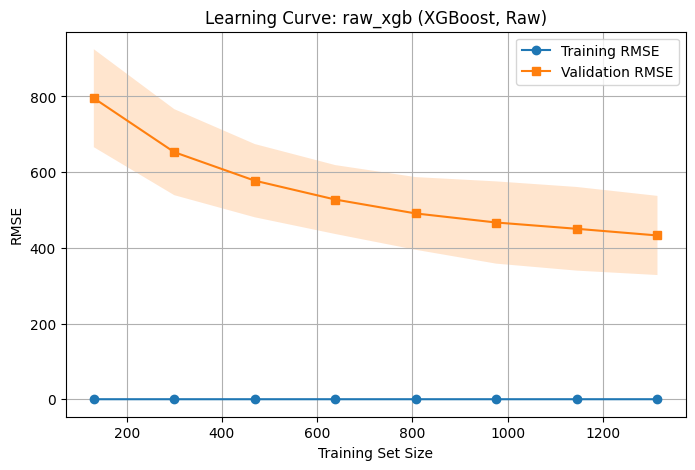

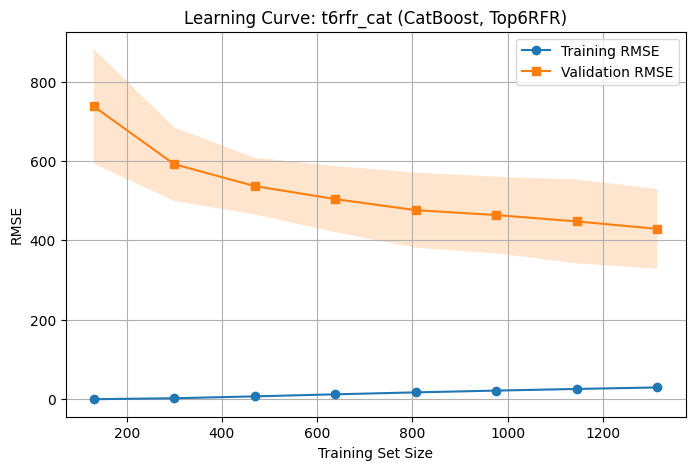

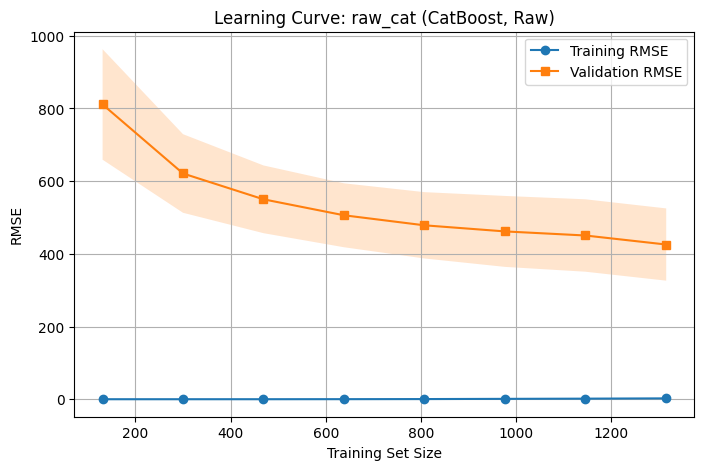

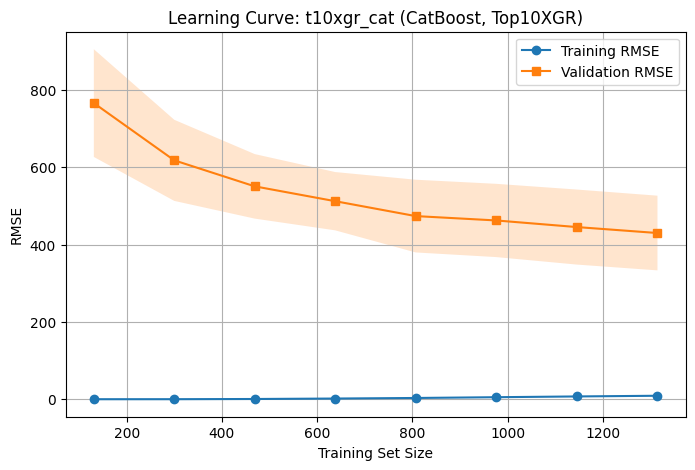

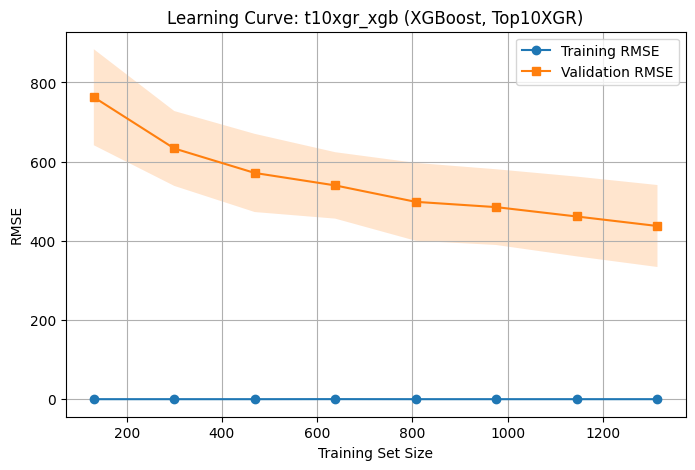

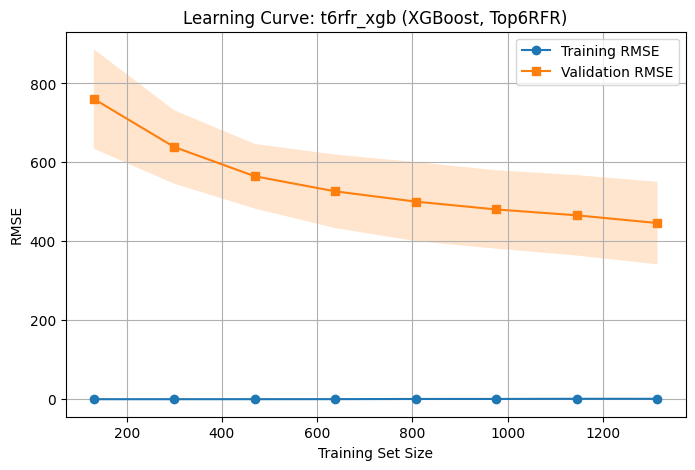

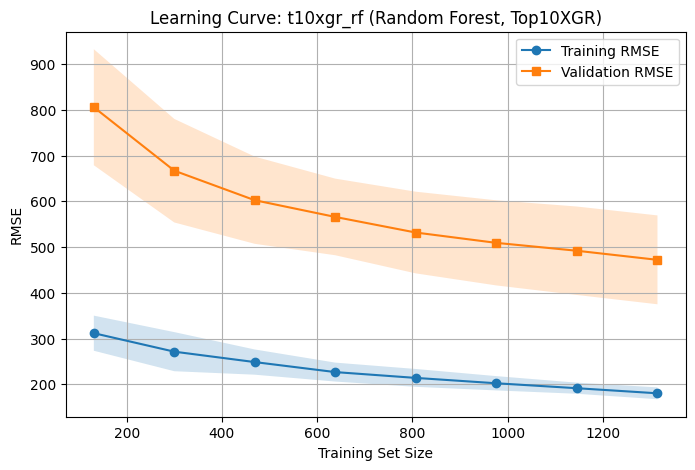

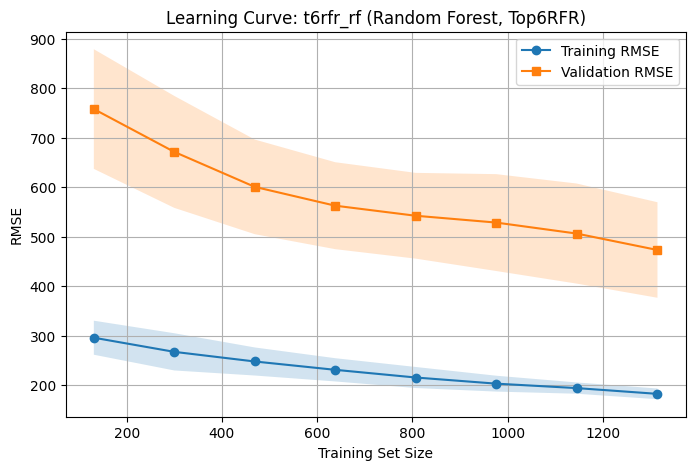

In [60]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import learning_curve, KFold
from sklearn.metrics import make_scorer, mean_squared_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

# CV for learning curves (training set only)
lc_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# RMSE scorer for learning_curve
def rmse_func(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse_func, greater_is_better=False)

# Train sizes
train_sizes = np.linspace(0.1, 1.0, 8)

# Loop through all 8 final tuned models
for _, row in finalists_df.iterrows():
    tag = row["tag"]
    data_kind = row["Data_Kind"]
    model_name = row["Model"]

    # Training data only
    X_train_lc = np.array(data_kinds[data_kind]["unscaled_train"])
    y_train_lc = np.array(y_train).ravel()

    # Get best hyperparameters from final grid search
    best_params = final_grid_objects[tag].best_params_

    # Rebuild clean estimator for learning curve
    # (no early stopping / no eval_set dependence)
    if model_name == "CatBoost":
        estimator = CatBoostRegressor(
            random_state=42,
            verbose=0,
            loss_function="RMSE",
            **best_params
        )

    elif model_name == "XGBoost":
        estimator = XGBRegressor(
            random_state=42,
            verbosity=0,
            objective="reg:squarederror",
            **best_params
        )

    elif model_name == "Random Forest":
        estimator = RandomForestRegressor(
            random_state=42,
            **best_params
        )

    # Compute learning curve
    sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X_train_lc,
        y=y_train_lc,
        train_sizes=train_sizes,
        cv=lc_cv,
        scoring=rmse_scorer,
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )

    # Convert negative RMSE back to positive RMSE
    train_rmse_mean = -np.mean(train_scores, axis=1)
    train_rmse_std = np.std(train_scores, axis=1)

    val_rmse_mean = -np.mean(val_scores, axis=1)
    val_rmse_std = np.std(val_scores, axis=1)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(sizes, train_rmse_mean, marker='o', label='Training RMSE')
    plt.plot(sizes, val_rmse_mean, marker='s', label='Validation RMSE')

    plt.fill_between(
        sizes,
        train_rmse_mean - train_rmse_std,
        train_rmse_mean + train_rmse_std,
        alpha=0.2
    )
    plt.fill_between(
        sizes,
        val_rmse_mean - val_rmse_std,
        val_rmse_mean + val_rmse_std,
        alpha=0.2
    )

    plt.title(f"Learning Curve: {tag} ({model_name}, {data_kind})")
    plt.xlabel("Training Set Size")
    plt.ylabel("RMSE")
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# All models exhibit decreasing validation error with increasing training size, indicating that additional data would further improve 
# performance. However, boosting models (CatBoost and XGBoost) show significant gaps between training and validation error, 
# suggesting high variance. Among all models, CatBoost with engineered features (Top6RFR) achieves the best generalization performance, 
# while Random Forest models display more stable but higher error due to increased bias.

# The learning curves suggest some overfitting in the boosting models; however, the final test-set ranking remained consistent. 
# Further improvements may be obtained in future work by reducing the number of trees or increasing regularization.

In [59]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

final_test_results = []

for _, row in finalists_df.iterrows():
    tag = row["tag"]
    data_kind = row["Data_Kind"]
    model_name = row["Model"]

    # Test data
    X_test = np.array(data_kinds[data_kind]["unscaled_test"])
    y_true = np.array(y_test).ravel()

    # Best trained model
    model = final_grid_objects[tag].best_estimator_

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    eps = 1e-8
    mapd = np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100
    stbd = np.std((y_true - y_pred) / (y_true + eps)) * 100

    final_test_results.append({
        "tag": tag,
        "Data_Kind": data_kind,
        "Model": model_name,
        "RMSE_test": rmse,
        "MAE_test": mae,
        "R2_test": r2,
        "MAPD_test": mapd,
        "STBD_test": stbd
    })

# Create DataFrame
final_test_results_df = pd.DataFrame(final_test_results)

# ✅ SORT: RMSE → MAE → R2 → MAPD
final_test_results_df = final_test_results_df.sort_values(
    by=["RMSE_test", "MAE_test", "R2_test", "MAPD_test"],
    ascending=[True, True, False, True]
).reset_index(drop=True)

# Add rank
final_test_results_df["Final_Rank"] = final_test_results_df.index + 1

final_test_results_df

,tag,Data_Kind,Model,RMSE_test,MAE_test,R2_test,MAPD_test,STBD_test,Final_Rank
0,t10xgr_cat,Top10XGR,CatBoost,467.231572,248.681017,0.903391,37.811085,371.912177,1
1,t6rfr_cat,Top6RFR,CatBoost,478.066137,245.942256,0.898858,34.619465,324.395151,2
2,t10xgr_xgb,Top10XGR,XGBoost,502.235307,260.169714,0.888373,45.262598,460.198758,3
3,t6rfr_xgb,Top6RFR,XGBoost,508.522818,255.326913,0.885561,41.395990,420.311829,4
4,raw_xgb,Raw,XGBoost,511.863732,249.659902,0.884052,27.029994,174.617224,5
5,raw_cat,Raw,CatBoost,514.170675,267.077131,0.883004,35.637599,302.439192,6
6,t10xgr_rf,Top10XGR,Random Forest,530.843747,263.526703,0.875294,33.220233,263.762880,7
7,t6rfr_rf,Top6RFR,Random Forest,532.314485,257.858642,0.874602,34.892909,314.919929,8


In [ ]:
# The comparison between K-fold cross-validation and final test set results shows strong consistency in model ranking, 
# indicating a robust model selection process. CatBoost models achieved the best performance in both stages, 
# with Top10XGR-CatBoost emerging as the top model on the test set (RMSE = 467.23, R² = 0.903). 
# While Top6RFR-CatBoost slightly outperformed in cross-validation, Top10XGR demonstrated better generalization. 
# XGBoost models showed stable but slightly inferior performance, whereas Random Forest exhibited the largest degradation from CV to test, 
# indicating weaker generalization. Overall, the consistency between CV and test results confirms that overfitting was minimal 
# and the selected models generalize well to unseen data.

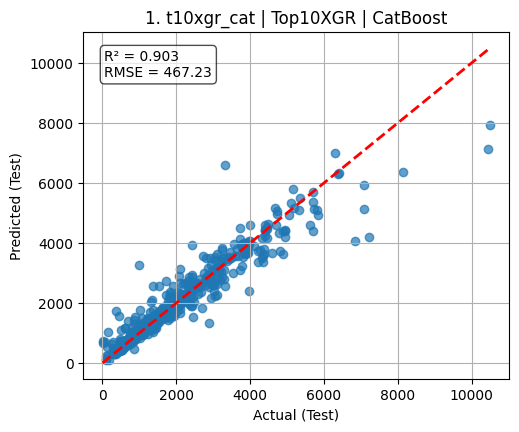

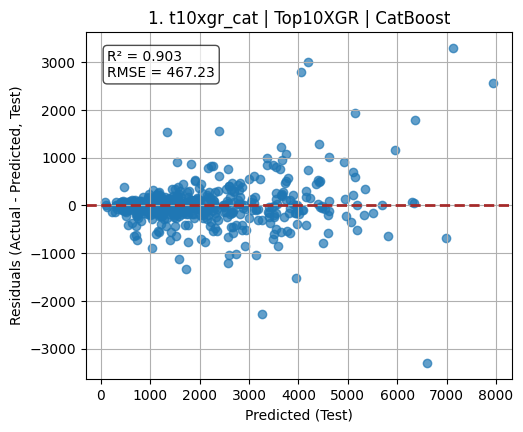

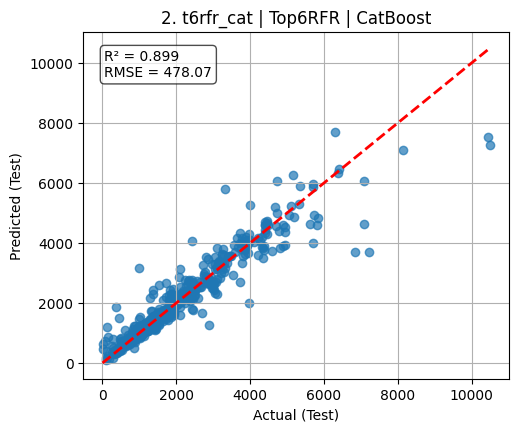

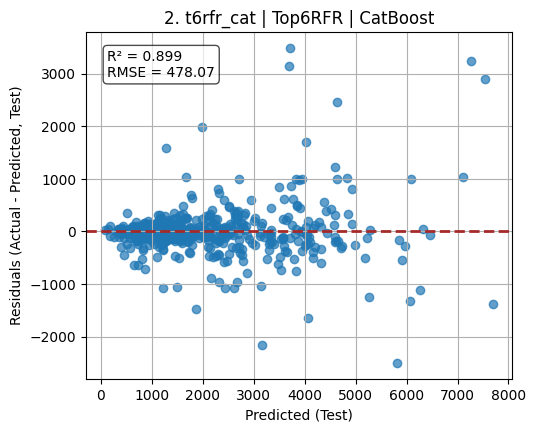

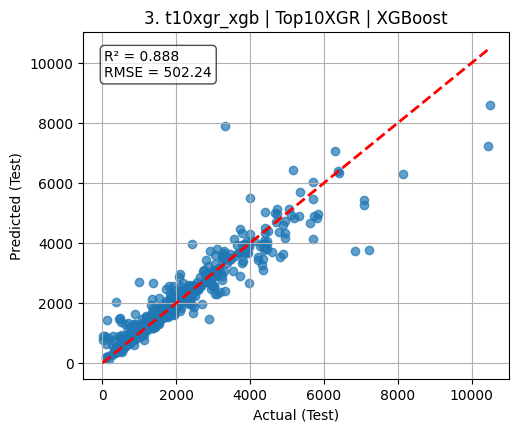

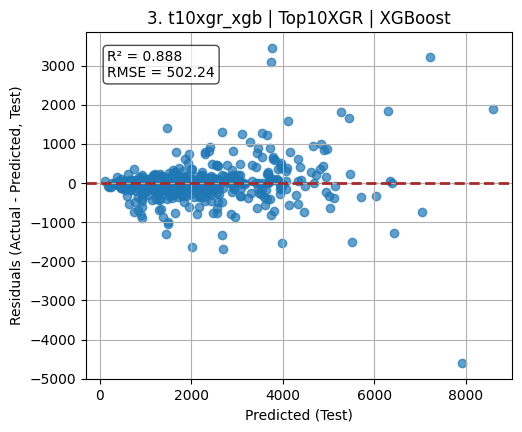

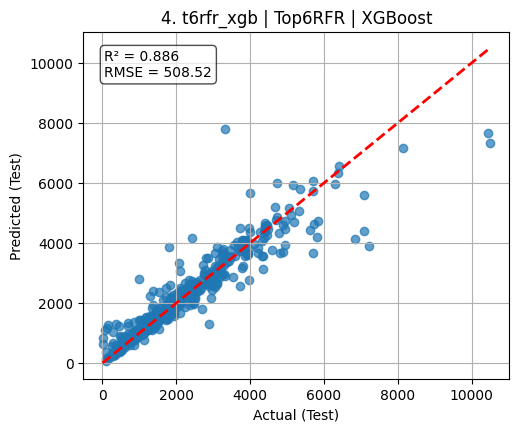

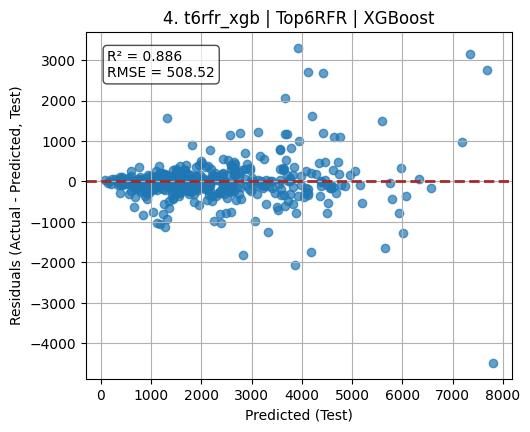

Top 4 models: 8 plots saved in → saved_top4_test_plots


In [62]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

save_dir = "saved_top4_test_plots"
os.makedirs(save_dir, exist_ok=True)

# ✅ Take only Top 4 models (already ranked)
top4 = final_test_results_df[["tag", "Data_Kind", "Model"]].head(4).copy()

y_test_use = np.ravel(y_test)

for rank, (_, row) in enumerate(top4.iterrows(), start=1):
    tag = row["tag"]
    data_kind = row["Data_Kind"]
    model_name = row["Model"]

    # Test data
    X_plot = np.array(data_kinds[data_kind]["unscaled_test"])
    y_true = y_test_use

    # Final tuned model
    tuned_model = final_grid_objects[tag].best_estimator_
    y_pred_test = tuned_model.predict(X_plot)

    residuals_test = y_true - y_pred_test
    mae_test = mean_absolute_error(y_true, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_true, y_pred_test))
    r2_test = r2_score(y_true, y_pred_test)

    stats_text = f"R² = {r2_test:.3f}\nRMSE = {rmse_test:.2f}"

    safe_tag = str(tag).replace(" ", "_")
    safe_model = str(model_name).replace(" ", "_").replace("(", "").replace(")", "")
    safe_data = str(data_kind).replace(" ", "_")

    # 🔹 Plot 1: Actual vs Predicted
    plt.figure(figsize=(5.5, 4.5))
    plt.scatter(y_true, y_pred_test, alpha=0.7)

    line_min = min(np.min(y_true), np.min(y_pred_test))
    line_max = max(np.max(y_true), np.max(y_pred_test))
    plt.plot([line_min, line_max], [line_min, line_max], '--', color='red', linewidth=2)

    plt.xlabel("Actual (Test)")
    plt.ylabel("Predicted (Test)")
    plt.title(f"{rank}. {tag} | {data_kind} | {model_name}")
    plt.grid(True)

    plt.text(
        0.05, 0.95, stats_text,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

    file1 = os.path.join(
        save_dir,
        f"{rank}_{safe_tag}_{safe_data}_{safe_model}_actual_vs_predicted_test.png"
    )
    plt.savefig(file1, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

    # 🔹 Plot 2: Residual vs Predicted
    plt.figure(figsize=(5.5, 4.5))
    plt.scatter(y_pred_test, residuals_test, alpha=0.7)

    plt.axhline(0, linestyle='--', color='brown', linewidth=2)

    plt.xlabel("Predicted (Test)")
    plt.ylabel("Residuals (Actual - Predicted, Test)")
    plt.title(f"{rank}. {tag} | {data_kind} | {model_name}")
    plt.grid(True)

    plt.text(
        0.05, 0.95, stats_text,
        transform=plt.gca().transAxes,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.7)
    )

    file2 = os.path.join(
        save_dir,
        f"{rank}_{safe_tag}_{safe_data}_{safe_model}_residual_vs_predicted_test.png"
    )
    plt.savefig(file2, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"Top 4 models: 8 plots saved in → {save_dir}")

In [66]:
df_train.columns

Index(['ID', 'Well_ID', 'test_hrs', 'choke_64', 'testline_psig', 'sbhp_psia',
       'fbhp_psia', 'fthp_psig', 'flp_ds_psig', 'annA_psig', 'annB_psig',
       'flow_temp_F', 'gl_gas_mmscfd', 'header_psig', 'sep_psig', 'sep_temp_F',
       'orifice_inch', 'gas_total_mmscfd', 'water_bpd', 'api', 'bsw_pct',
       'Oil (BPD)'],
      dtype='str')

In [68]:
import pandas as pd

# This block computes summary statistics for selected features in both the
# training and test datasets. For each feature, key statistical measures
# including minimum, maximum, mean, median, variance, and standard deviation
# are calculated to characterize the data distribution. These summaries are
# used to verify consistency between training and test sets and to provide
# a baseline understanding of feature ranges and variability.

features = ["choke_64", "bsw_pct", "fthp_psig", "water_bpd", "Oil (BPD)"]

def summary_table(df, features):
    summary = pd.DataFrame({
        "Features": features,
        "Minimum": [df[col].min() for col in features],
        "Maximum": [df[col].max() for col in features],
        "Mean": [df[col].mean() for col in features],
        "Median": [df[col].median() for col in features],
        "Variance": [df[col].var() for col in features],
        "Standard deviation": [df[col].std() for col in features],
    })
    return summary.round(2)

train_summary = summary_table(df_train, features)
test_summary  = summary_table(df_test, features)

print("Table 1: The train data summary statistics")
display(train_summary)

Table 1: The train data summary statistics


,Features,Minimum,Maximum,Mean,Median,Variance,Standard deviation
0,choke_64,12.0,137.00,74.35,70.0,1236.01,35.16
1,bsw_pct,0.0,97.33,42.18,47.0,968.36,31.12
2,fthp_psig,82.0,1665.70,316.22,259.3,37116.94,192.66
3,water_bpd,0.0,7268.00,1650.69,1301.6,2539896.43,1593.71
4,Oil (BPD),30.8,10618.00,1859.35,1433.0,1867166.52,1366.44


In [69]:
print("Table 2: The test data summary statistics")
display(test_summary)

Table 2: The test data summary statistics


,Features,Minimum,Maximum,Mean,Median,Variance,Standard deviation
0,choke_64,10.0,137.0,73.54,70.0,1153.93,33.97
1,bsw_pct,0.0,95.0,40.20,46.0,934.09,30.56
2,fthp_psig,105.0,3255.0,329.09,265.7,51695.13,227.37
3,water_bpd,0.0,6500.0,1541.13,1202.2,2323848.72,1524.42
4,Oil (BPD),9.0,10498.0,1992.42,1528.5,2263793.84,1504.59


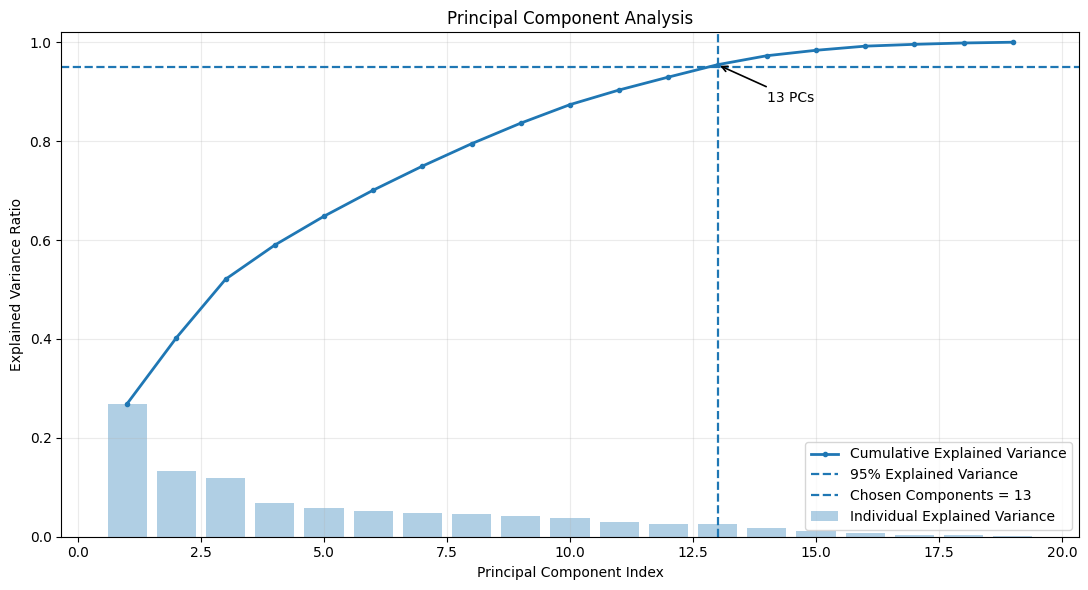

In [86]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# This block performs PCA on the scaled training data to analyze how variance
# is distributed across principal components. The individual and cumulative
# explained variance are computed and visualized to identify the number of
# components required to capture a desired level of information (e.g., 95%).
# The plot highlights this threshold, providing a basis for dimensionality
# reduction while retaining the dominant structure in the data.

pca_full = PCA()
pca_full.fit(x_train_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)
n_95 = np.argmax(cum_explained_var >= 0.95) + 1
components = np.arange(1, len(explained_var) + 1)

plt.figure(figsize=(11, 6))

plt.bar(
    components,
    explained_var,
    alpha=0.35,
    width=0.8,
    label="Individual Explained Variance"
)

plt.plot(
    components,
    cum_explained_var,
    marker="o",
    markersize=3,
    linewidth=2,
    label="Cumulative Explained Variance"
)

plt.axhline(0.95, linestyle="--", linewidth=1.6, label="95% Explained Variance")
plt.axvline(n_95, linestyle="--", linewidth=1.6, label=f"Chosen Components = {n_95}")

plt.annotate(
    f"{n_95} PCs",
    xy=(n_95, cum_explained_var[n_95 - 1]),
    xytext=(n_95 + 1, 0.88),
    arrowprops=dict(arrowstyle="->", lw=1.2),
    fontsize=10
)

plt.title("Principal Component Analysis")
plt.xlabel("Principal Component Index")
plt.ylabel("Explained Variance Ratio")
plt.ylim(0, 1.02)
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

# print(f"95% of explained variance is captured by the first {n_95} principal components.")